# COMPAS Notebook 2 — Models, Group-wise Metrics, SHAP, LIME, Group-wise SHAP
## Bias Analysis in ML Models using Explainable AI

**Primary harm metric:** FPR — wrongly flagging a person as high-risk when they will NOT reoffend  
**Sensitive attributes:** `race`, `sex`, `age_cat`  
**Models:** LR Balanced, DT Balanced (same pipeline as Adult Census)

---

### What this notebook covers

- **Part 1:** Train LR Balanced and DT Balanced
- **Part 2:** Group-wise metrics (accuracy, FPR, FNR) by race, sex, age_cat, and intersectional
- **Part 3:** Global SHAP + individual waterfall plots (Individuals A, B, C)
- **Part 4:** LIME on same three individuals
- **Part 5:** Group-wise SHAP (sex, race, intersectional)

### Individual selection rationale

- **Individual A:** Correctly classified Black male (True Positive — predicted high risk, did reoffend)
- **Individual B:** Correctly classified White male (True Positive — predicted high risk, did reoffend)
- **Individual C:** Misclassified Black male (False Positive — predicted high risk, did NOT reoffend)

Individual C is the primary case of interest — a false positive on a Black defendant is the exact harm ProPublica documented.

---
## 0. Imports and Load Artefacts

In [1]:
import sys
print(sys.executable)

c:\Users\HP\anaconda3\python.exe


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lime
import lime.lime_tabular
import joblib
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

warnings.filterwarnings('ignore')
shap.initjs()
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

RANDOM_STATE = 42
MIN_GROUP_SIZE = 30
print('Imports complete.')

Imports complete.


In [3]:
X_train   = pd.read_csv('compas_X_train.csv')
X_test    = pd.read_csv('compas_X_test.csv')
y_train   = pd.read_csv('compas_y_train.csv').squeeze()
y_test    = pd.read_csv('compas_y_test.csv').squeeze()
sensitive = pd.read_csv('compas_sensitive_test.csv')

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'Features: {X_train.columns.tolist()}')

X_train: (4937, 9), X_test: (1235, 9)
Features: ['age', 'age_cat', 'sex', 'race', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count', 'c_charge_degree']


---
## Part 1 — Train Models

### 1.1 DT Balanced — Depth Sweep

  depth=2: recall=0.750
  depth=3: recall=0.621
  depth=4: recall=0.656
  depth=5: recall=0.626
  depth=6: recall=0.657
  depth=7: recall=0.643
  depth=8: recall=0.628
  depth=9: recall=0.621
  depth=10: recall=0.604

Best depth by recall: 2


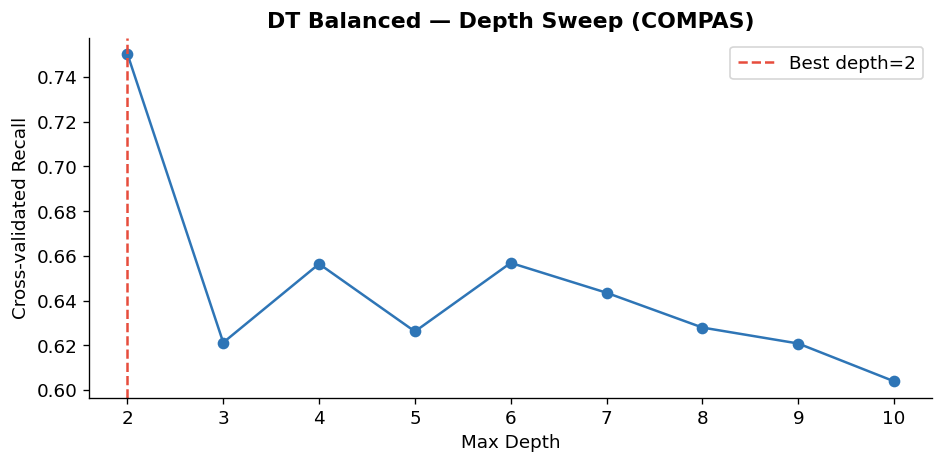

In [4]:
depths = range(2, 11)
recall_scores = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=RANDOM_STATE)
    score = cross_val_score(dt, X_train, y_train, cv=5, scoring='recall').mean()
    recall_scores.append(score)
    print(f'  depth={d}: recall={score:.3f}')

best_depth = list(depths)[np.argmax(recall_scores)]
print(f'\nBest depth by recall: {best_depth}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(depths), recall_scores, marker='o', color='#2E75B6')
ax.axvline(best_depth, color='#e74c3c', linestyle='--', label=f'Best depth={best_depth}')
ax.set_xlabel('Max Depth')
ax.set_ylabel('Cross-validated Recall')
ax.set_title('DT Balanced — Depth Sweep (COMPAS)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('compas_depth_sweep.png', bbox_inches='tight')
plt.show()

In [5]:
dt_bal = DecisionTreeClassifier(max_depth=best_depth, class_weight='balanced', random_state=RANDOM_STATE)
dt_bal.fit(X_train, y_train)

lr_bal = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
lr_bal.fit(X_train, y_train)

y_pred_dt = dt_bal.predict(X_test)
y_pred_lr = lr_bal.predict(X_test)
y_prob_dt = dt_bal.predict_proba(X_test)[:, 1]
y_prob_lr = lr_bal.predict_proba(X_test)[:, 1]

print('DT Balanced:')
print(classification_report(y_test, y_pred_dt))
print('\nLR Balanced:')
print(classification_report(y_test, y_pred_lr))

joblib.dump(dt_bal, 'compas_dt_balanced_model.pkl')
joblib.dump(lr_bal, 'compas_lr_balanced_model.pkl')
pd.Series(y_pred_dt).to_csv('compas_predictions_dt_bal.csv', index=False)
pd.Series(y_pred_lr).to_csv('compas_predictions_lr_bal.csv', index=False)
print('Models saved.')

DT Balanced:
              precision    recall  f1-score   support

           0       0.74      0.48      0.58       673
           1       0.56      0.79      0.66       562

    accuracy                           0.62      1235
   macro avg       0.65      0.64      0.62      1235
weighted avg       0.66      0.62      0.62      1235


LR Balanced:
              precision    recall  f1-score   support

           0       0.71      0.71      0.71       673
           1       0.65      0.66      0.65       562

    accuracy                           0.69      1235
   macro avg       0.68      0.68      0.68      1235
weighted avg       0.69      0.69      0.69      1235

Models saved.


---
## Part 2 — Group-wise Metrics

FPR is the primary harm metric throughout. A false positive means a person who will NOT reoffend is wrongly flagged high-risk.

In [6]:
def group_metrics(y_true, y_pred, sensitive_col, model_name='Model'):
    results = []
    for group in sensitive_col.unique():
        mask = (sensitive_col == group)
        n = mask.sum()
        if n < MIN_GROUP_SIZE:
            print(f'  Skipping {group} (n={n})')
            continue
        yt = y_true[mask]
        yp = y_pred[mask]
        cm = confusion_matrix(yt, yp, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        accuracy = (tp + tn) / (tp + tn + fp + fn)
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        results.append({'Group': group, 'N': n, 'Accuracy': round(accuracy, 3),
                         'FPR': round(fpr, 3), 'FNR': round(fnr, 3), 'Model': model_name})
    return pd.DataFrame(results)


def plot_group_metrics(metrics_df, sensitive_name, model_name):
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    colors = {'Accuracy': '#2E75B6', 'FPR': '#e74c3c', 'FNR': '#e67e22'}
    for ax, metric in zip(axes, ['Accuracy', 'FPR', 'FNR']):
        ax.bar(metrics_df['Group'], metrics_df[metric], color=colors[metric], alpha=0.85)
        ax.set_title(f'{metric} by {sensitive_name}', fontweight='bold')
        ax.set_ylabel(metric)
        ax.set_xticklabels(metrics_df['Group'], rotation=30, ha='right')
        ax.set_ylim(0, 1)
        if metric == 'FPR':
            ax.set_facecolor('#fff5f5')  # highlight primary harm
    plt.suptitle(f'{model_name} — Group-wise Metrics by {sensitive_name}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'compas_metrics_{sensitive_name}_{model_name.replace(" ","_")}.png',
                bbox_inches='tight')
    plt.show()

print('Functions defined.')

Functions defined.


  Skipping Asian (n=7)
  Skipping Native American (n=1)
  Skipping Asian (n=7)
  Skipping Native American (n=1)
DT Balanced — by Race:
           Group   N  Accuracy   FPR   FNR       Model
African-American 641     0.641 0.638 0.107 DT Balanced
        Hispanic  94     0.596 0.449 0.356 DT Balanced
           Other  65     0.569 0.447 0.389 DT Balanced
       Caucasian 427     0.609 0.410 0.360 DT Balanced

LR Balanced — by Race:
           Group   N  Accuracy   FPR   FNR       Model
African-American 641     0.699 0.408 0.205 LR Balanced
        Hispanic  94     0.638 0.245 0.489 LR Balanced
       Caucasian 427     0.656 0.207 0.571 LR Balanced
           Other  65     0.769 0.106 0.556 LR Balanced


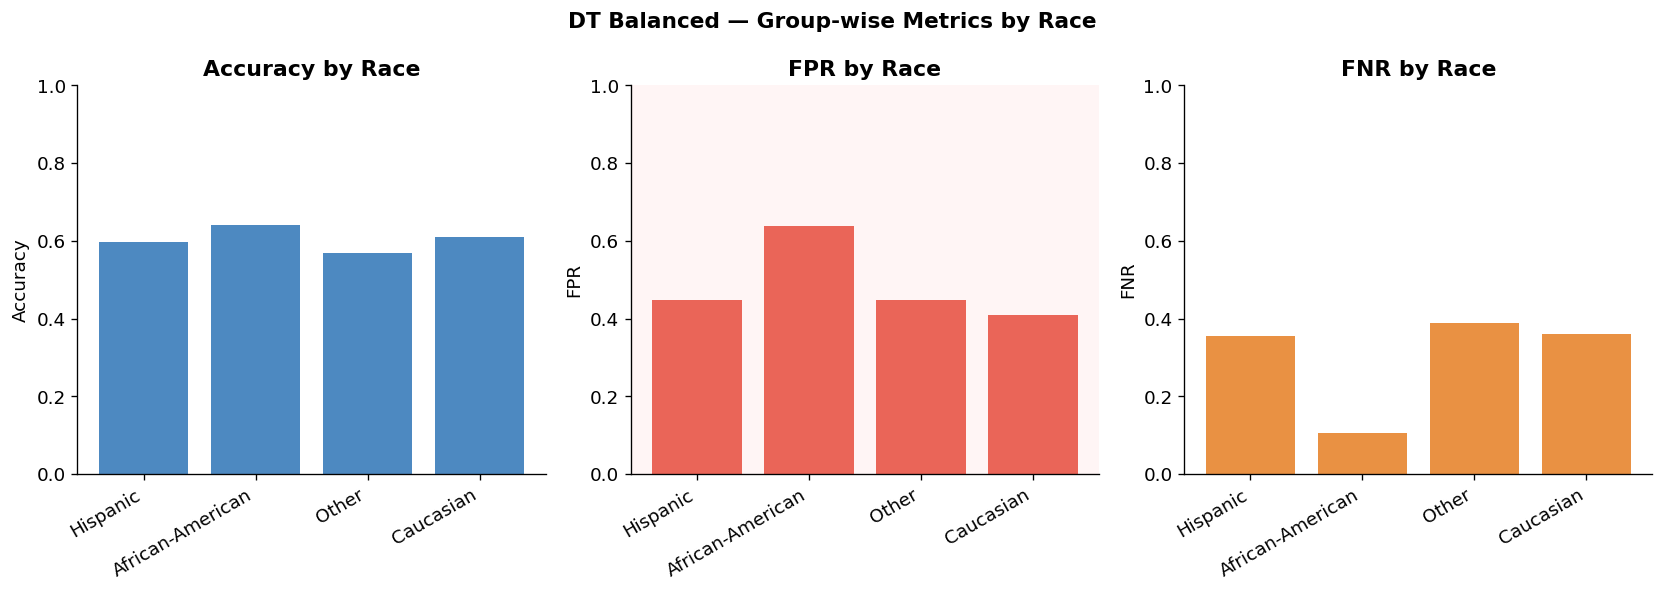

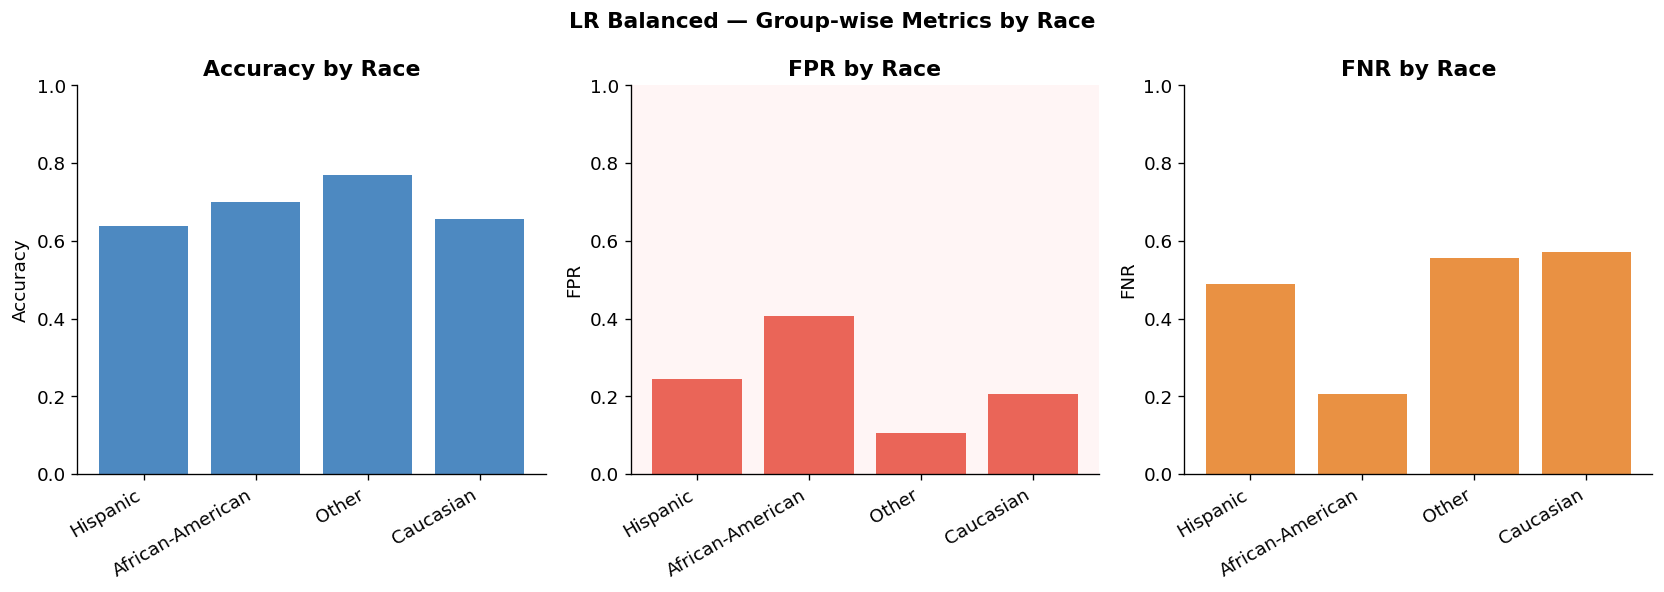

In [7]:
# By Race
m_race_dt = group_metrics(y_test, y_pred_dt, sensitive['race'], 'DT Balanced')
m_race_lr = group_metrics(y_test, y_pred_lr, sensitive['race'], 'LR Balanced')
print('DT Balanced — by Race:')
print(m_race_dt.sort_values('FPR', ascending=False).to_string(index=False))
print('\nLR Balanced — by Race:')
print(m_race_lr.sort_values('FPR', ascending=False).to_string(index=False))
plot_group_metrics(m_race_dt, 'Race', 'DT Balanced')
plot_group_metrics(m_race_lr, 'Race', 'LR Balanced')

DT Balanced — by Sex:
 Group    N  Accuracy   FPR   FNR       Model
  Male 1002     0.638 0.528 0.180 DT Balanced
Female  233     0.562 0.480 0.365 DT Balanced


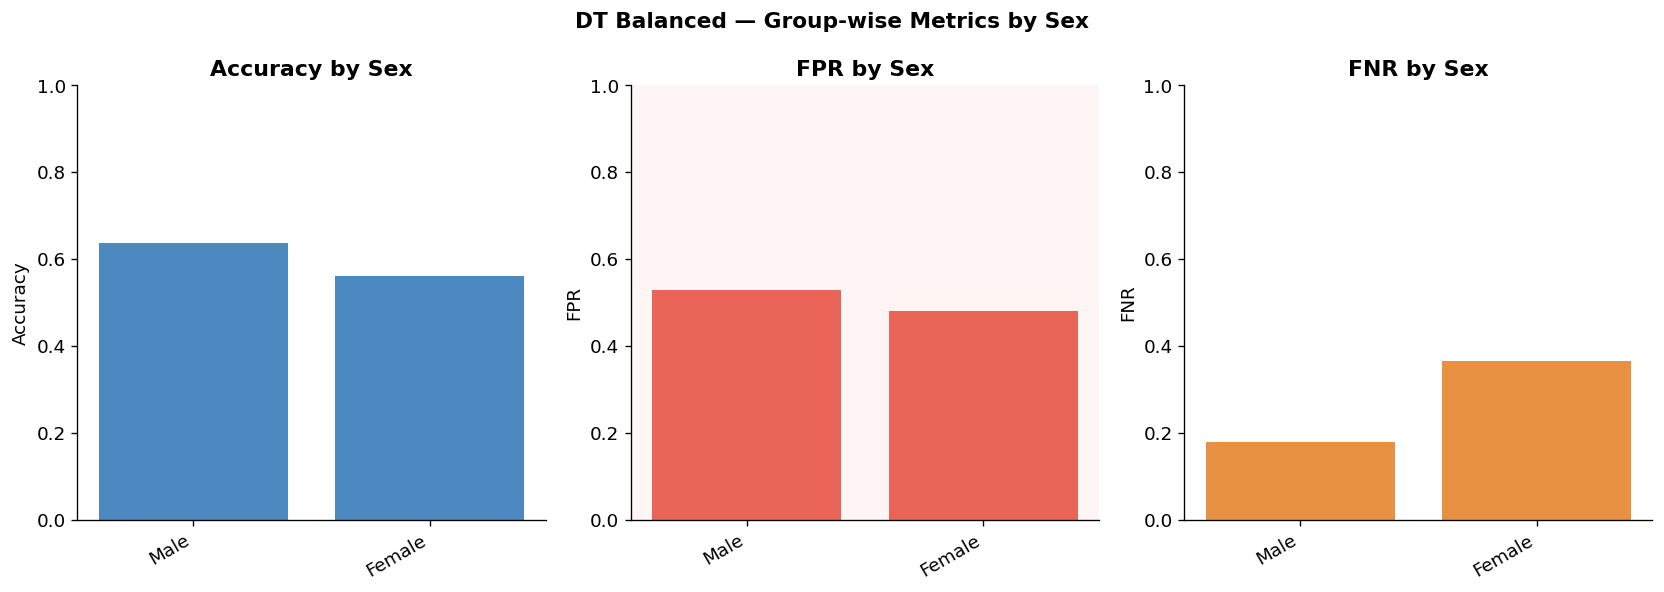

In [8]:
# By Sex
m_sex_dt = group_metrics(y_test, y_pred_dt, sensitive['sex'], 'DT Balanced')
m_sex_lr = group_metrics(y_test, y_pred_lr, sensitive['sex'], 'LR Balanced')
print('DT Balanced — by Sex:')
print(m_sex_dt.to_string(index=False))
plot_group_metrics(m_sex_dt, 'Sex', 'DT Balanced')

DT Balanced — by Age:
          Group   N  Accuracy   FPR   FNR       Model
   Less than 25 288     0.562 1.000 0.000 DT Balanced
        25 - 45 661     0.626 0.483 0.252 DT Balanced
Greater than 45 286     0.678 0.271 0.437 DT Balanced


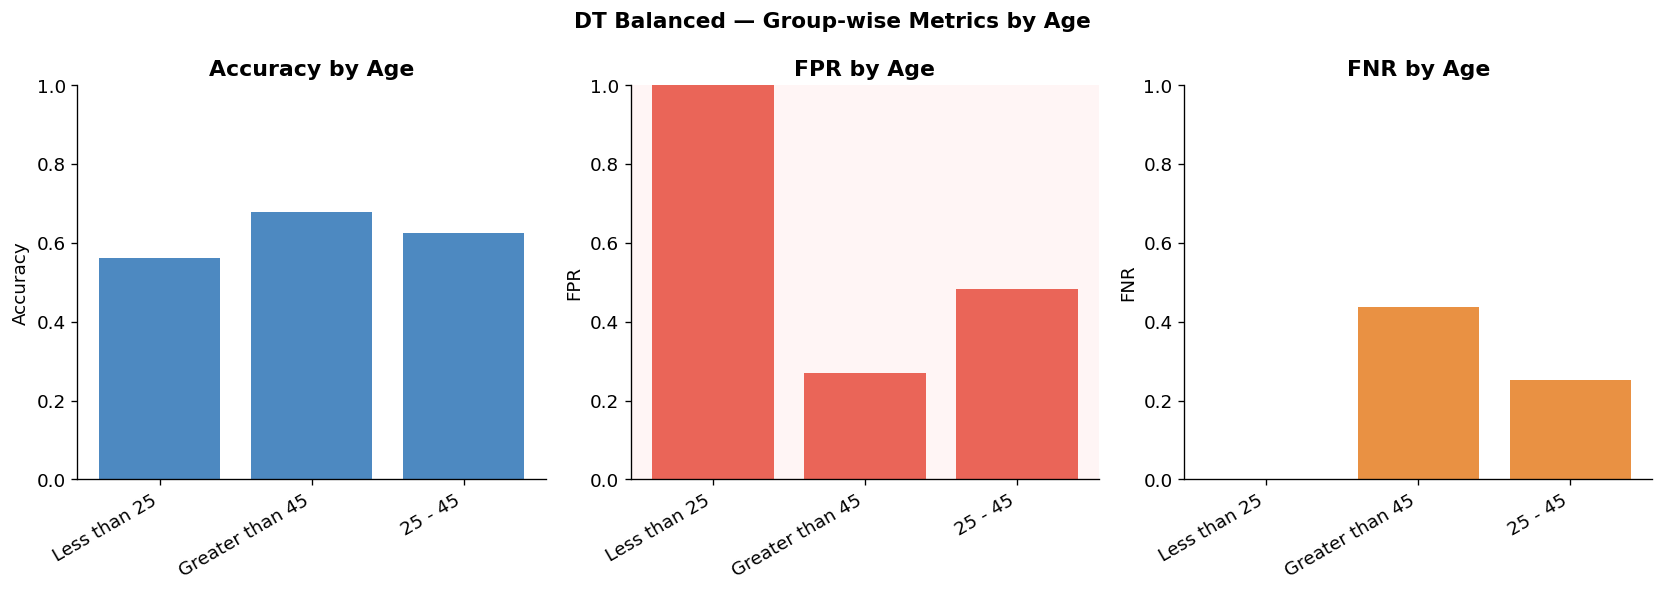

In [9]:
# By Age Category
m_age_dt = group_metrics(y_test, y_pred_dt, sensitive['age_cat'], 'DT Balanced')
m_age_lr = group_metrics(y_test, y_pred_lr, sensitive['age_cat'], 'LR Balanced')
print('DT Balanced — by Age:')
print(m_age_dt.sort_values('FPR', ascending=False).to_string(index=False))
plot_group_metrics(m_age_dt, 'Age', 'DT Balanced')

  Skipping Male_Asian (n=7)
  Skipping Female_Other (n=13)
  Skipping Female_Hispanic (n=18)
  Skipping Male_Native American (n=1)
Intersectional (Sex x Race) — DT Balanced (sorted by FPR):
                  Group   N  Accuracy   FPR   FNR       Model
  Male_African-American 525     0.655 0.658 0.099 DT Balanced
Female_African-American 116     0.578 0.575 0.163 DT Balanced
             Male_Other  52     0.558 0.471 0.389 DT Balanced
          Male_Hispanic  76     0.658 0.439 0.229 DT Balanced
         Male_Caucasian 341     0.616 0.420 0.326 DT Balanced
       Female_Caucasian  86     0.581 0.370 0.500 DT Balanced


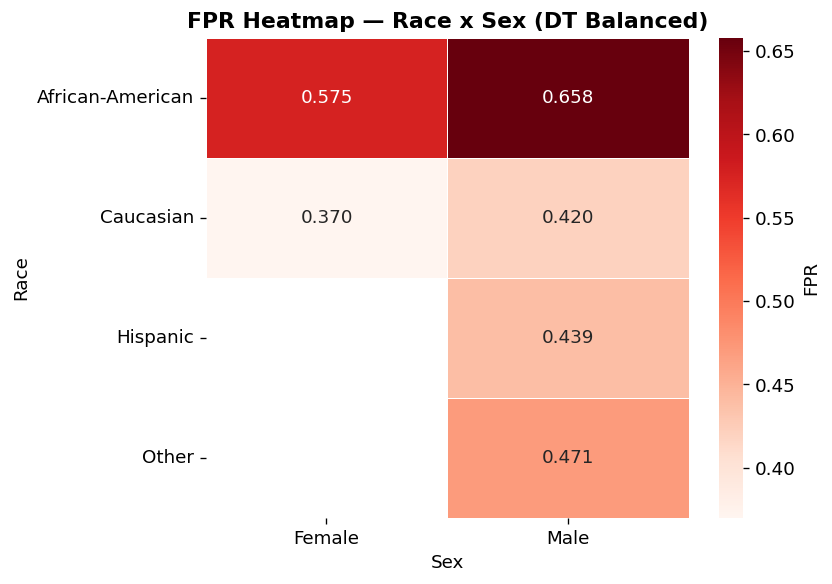

In [10]:
# Intersectional: Race x Sex
m_intersect_dt = group_metrics(y_test, y_pred_dt, sensitive['sex_race'], 'DT Balanced')
print('Intersectional (Sex x Race) — DT Balanced (sorted by FPR):')
print(m_intersect_dt.sort_values('FPR', ascending=False).to_string(index=False))

# FPR heatmap
pivot = m_intersect_dt.copy()
pivot[['Sex', 'Race']] = pivot['Group'].str.split('_', n=1, expand=True)
try:
    fpr_heatmap = pivot.pivot(index='Race', columns='Sex', values='FPR')
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(fpr_heatmap, annot=True, fmt='.3f', cmap='Reds', ax=ax,
                linewidths=0.5, cbar_kws={'label': 'FPR'})
    ax.set_title('FPR Heatmap — Race x Sex (DT Balanced)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('compas_fpr_heatmap.png', bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f'Heatmap could not be generated: {e}')

---
## Part 3 — Global SHAP and Individual Waterfall Plots

In [12]:
explainer_dt = shap.TreeExplainer(dt_bal)
shap_values_dt = explainer_dt.shap_values(X_test)
if isinstance(shap_values_dt, np.ndarray) and shap_values_dt.ndim == 3:
    sv_dt = shap_values_dt[:, :, 1] 
else:
    # Older versions of SHAP return a list for trees
    sv_dt = shap_values_dt[1] if isinstance(shap_values_dt, list) else shap_values_dt

explainer_lr = shap.LinearExplainer(lr_bal, X_test)
sv_lr = explainer_lr.shap_values(X_test)

shap_dt_df = pd.DataFrame(sv_dt, columns=X_test.columns)
shap_lr_df = pd.DataFrame(sv_lr, columns=X_test.columns)

print(f'SHAP computed. DT shape: {sv_dt.shape}')

SHAP computed. DT shape: (1235, 9)


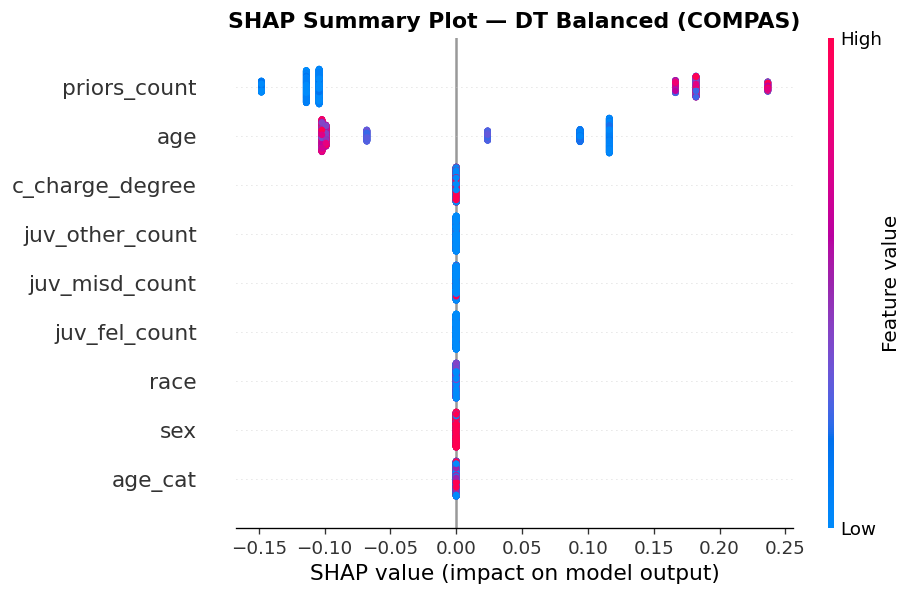

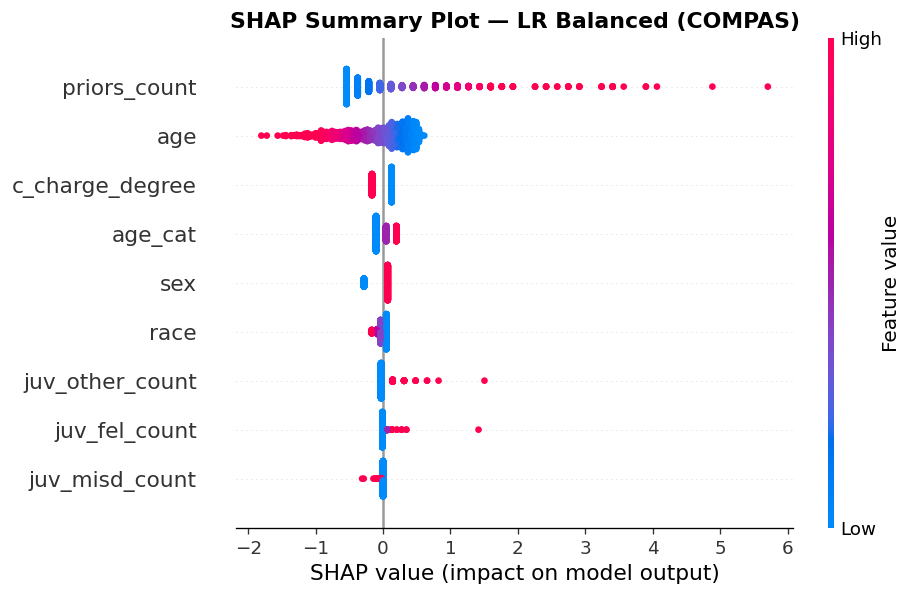

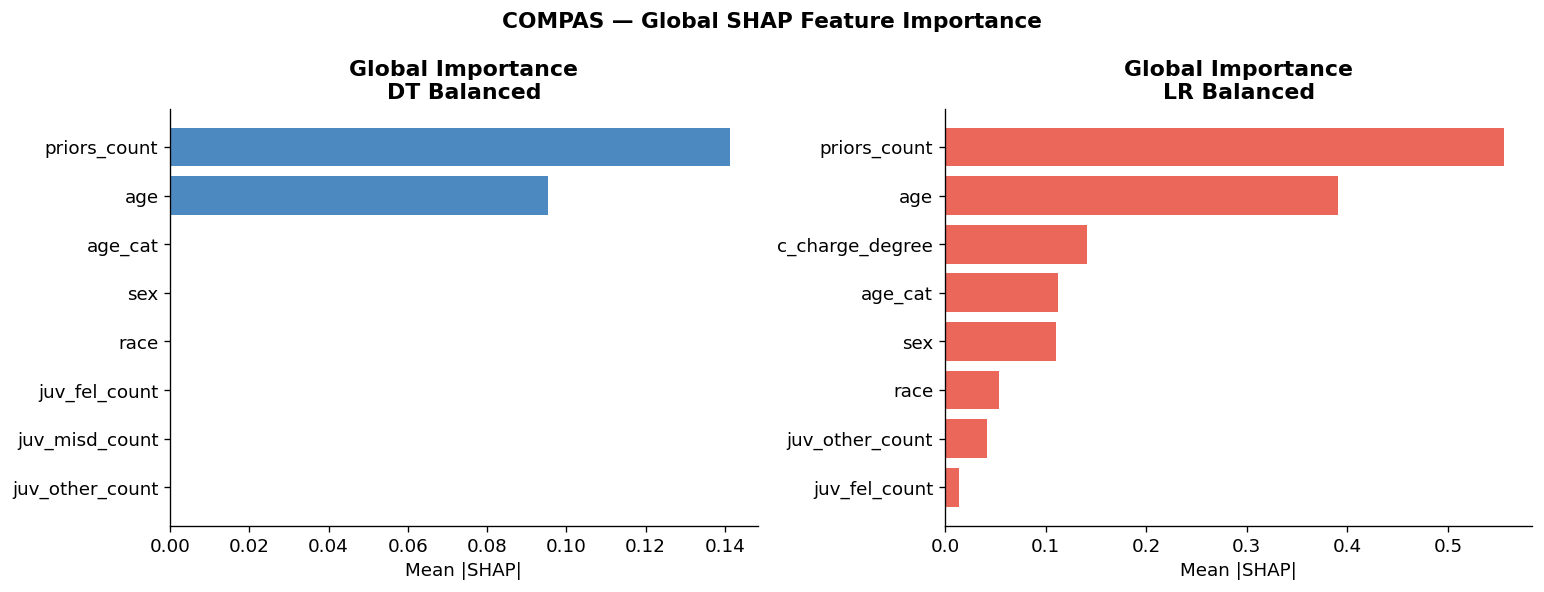

Top-5 DT Balanced:
priors_count    0.1412
age             0.0954
age_cat         0.0000
sex             0.0000
race            0.0000
dtype: float64

Top-5 LR Balanced:
priors_count       0.5563
age                0.3912
c_charge_degree    0.1413
age_cat            0.1119
sex                0.1103
dtype: float64


In [13]:
# Global summary plots
for sv, title in [(sv_dt, 'DT Balanced'), (sv_lr, 'LR Balanced')]:
    plt.figure(figsize=(9, 6))
    shap.summary_plot(sv, X_test, show=False)
    plt.title(f'SHAP Summary Plot — {title} (COMPAS)', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'compas_shap_summary_{title.replace(" ","_")}.png', bbox_inches='tight')
    plt.show()

# Global importance bar chart
mean_abs_dt = shap_dt_df.abs().mean().sort_values(ascending=False)
mean_abs_lr = shap_lr_df.abs().mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, mean_abs, title, color in zip(
    axes, [mean_abs_dt, mean_abs_lr], ['DT Balanced', 'LR Balanced'], ['#2E75B6', '#e74c3c']
):
    top = mean_abs.head(8)[::-1]
    ax.barh(top.index, top.values, color=color, alpha=0.85)
    ax.set_title(f'Global Importance\n{title}', fontweight='bold')
    ax.set_xlabel('Mean |SHAP|')
plt.suptitle('COMPAS — Global SHAP Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('compas_shap_global_importance.png', bbox_inches='tight')
plt.show()

print('Top-5 DT Balanced:')
print(mean_abs_dt.head(5).round(4))
print('\nTop-5 LR Balanced:')
print(mean_abs_lr.head(5).round(4))

In [14]:
# Select Individuals A, B, C
df_eval = sensitive.copy()
df_eval['y_true']    = y_test.values
df_eval['y_pred_dt'] = y_pred_dt
df_eval['y_prob_dt'] = y_prob_dt

# Individual A: Black male TP
mask_A = ((df_eval['race']=='African-American') & (df_eval['sex']=='Male') &
          (df_eval['y_true']==1) & (df_eval['y_pred_dt']==1))
idx_A = df_eval[mask_A].index[0]

# Individual B: White male TP
mask_B = ((df_eval['race']=='Caucasian') & (df_eval['sex']=='Male') &
          (df_eval['y_true']==1) & (df_eval['y_pred_dt']==1))
idx_B = df_eval[mask_B].index[0]

# Individual C: Black male FP
mask_C = ((df_eval['race']=='African-American') & (df_eval['sex']=='Male') &
          (df_eval['y_true']==0) & (df_eval['y_pred_dt']==1))
idx_C = df_eval[mask_C].index[0]

for idx, label in [(idx_A,'Individual A — Black Male TP'), (idx_B,'Individual B — White Male TP'),
                    (idx_C,'Individual C — Black Male FP')]:
    print(f'{label}: index={idx}, P(reoffend)={y_prob_dt[idx]:.3f}')
    print(X_test.iloc[idx].to_dict())
    print()

Individual A — Black Male TP: index=4, P(reoffend)=0.583
{'age': 35, 'age_cat': 0, 'sex': 1, 'race': 0, 'juv_fel_count': 0, 'juv_misd_count': 0, 'juv_other_count': 0, 'priors_count': 7, 'c_charge_degree': 0}

Individual B — White Male TP: index=30, P(reoffend)=0.583
{'age': 36, 'age_cat': 0, 'sex': 1, 'race': 2, 'juv_fel_count': 0, 'juv_misd_count': 0, 'juv_other_count': 0, 'priors_count': 5, 'c_charge_degree': 0}

Individual C — Black Male FP: index=1, P(reoffend)=0.583
{'age': 50, 'age_cat': 1, 'sex': 1, 'race': 0, 'juv_fel_count': 1, 'juv_misd_count': 0, 'juv_other_count': 0, 'priors_count': 5, 'c_charge_degree': 0}



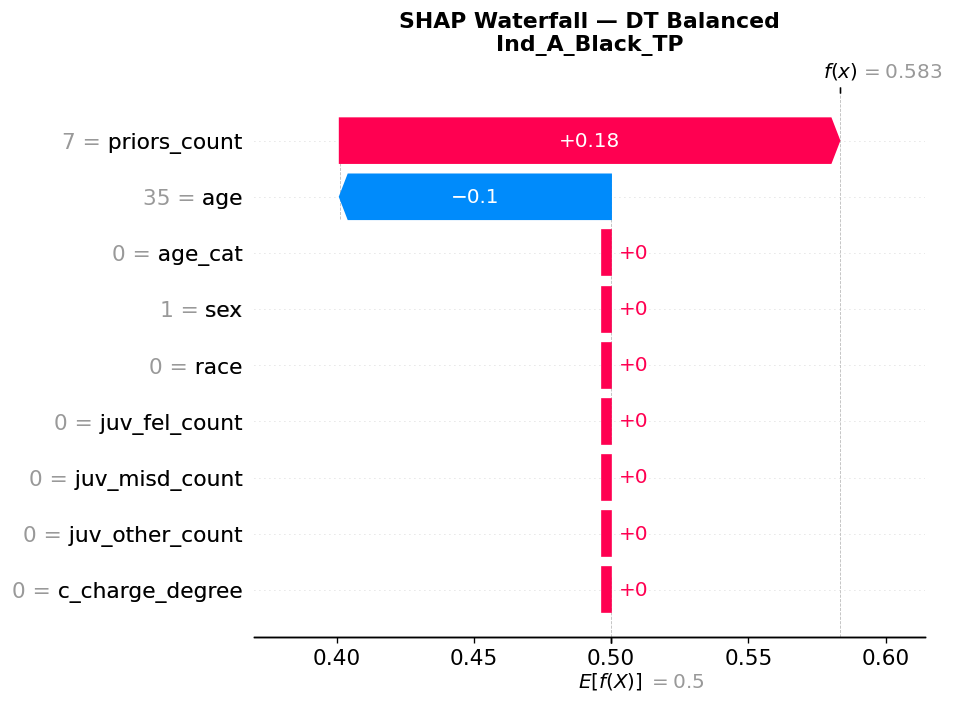

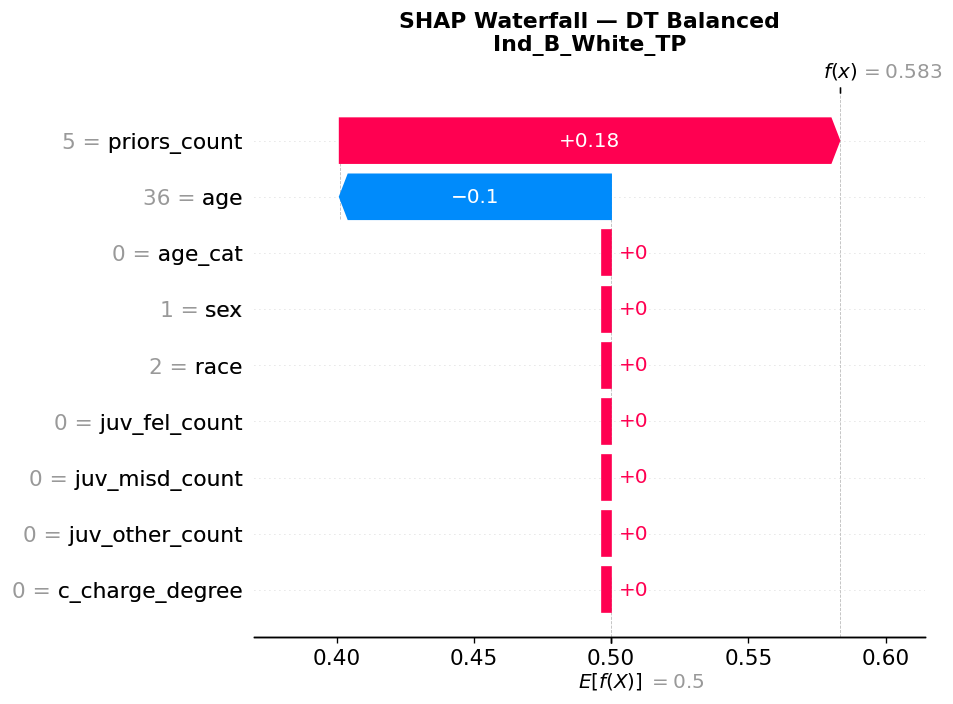

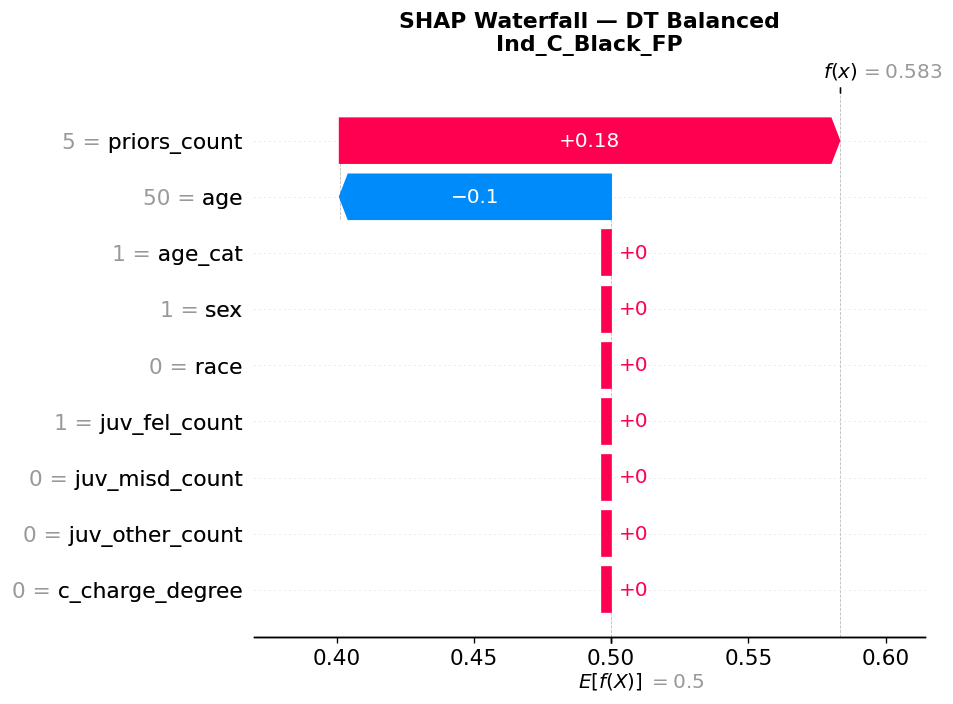

In [15]:
# Waterfall plots — DT Balanced
shap_exp = shap.TreeExplainer(dt_bal)(X_test)

for idx, label in [(idx_A,'Ind_A_Black_TP'), (idx_B,'Ind_B_White_TP'), (idx_C,'Ind_C_Black_FP')]:
    plt.figure()
    try:
        if len(shap_exp.values.shape) == 3:
            exp = shap.Explanation(
                values=shap_exp.values[idx, :, 1],
                base_values=shap_exp.base_values[idx, 1],
                data=shap_exp.data[idx],
                feature_names=X_test.columns.tolist()
            )
        else:
            exp = shap_exp[idx]
        shap.plots.waterfall(exp, show=False)
    except Exception:
        shap.waterfall_plot(shap.Explanation(
            values=sv_dt[idx], base_values=explainer_dt.expected_value[1]
                if isinstance(explainer_dt.expected_value, list) else explainer_dt.expected_value,
            data=X_test.iloc[idx].values,
            feature_names=X_test.columns.tolist()
        ), show=False)
    plt.title(f'SHAP Waterfall — DT Balanced\n{label}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'compas_waterfall_{label}.png', bbox_inches='tight')
    plt.show()

---
## Part 4 — LIME on Three Individuals


 AUDITING: Individual A (Black Male TP)


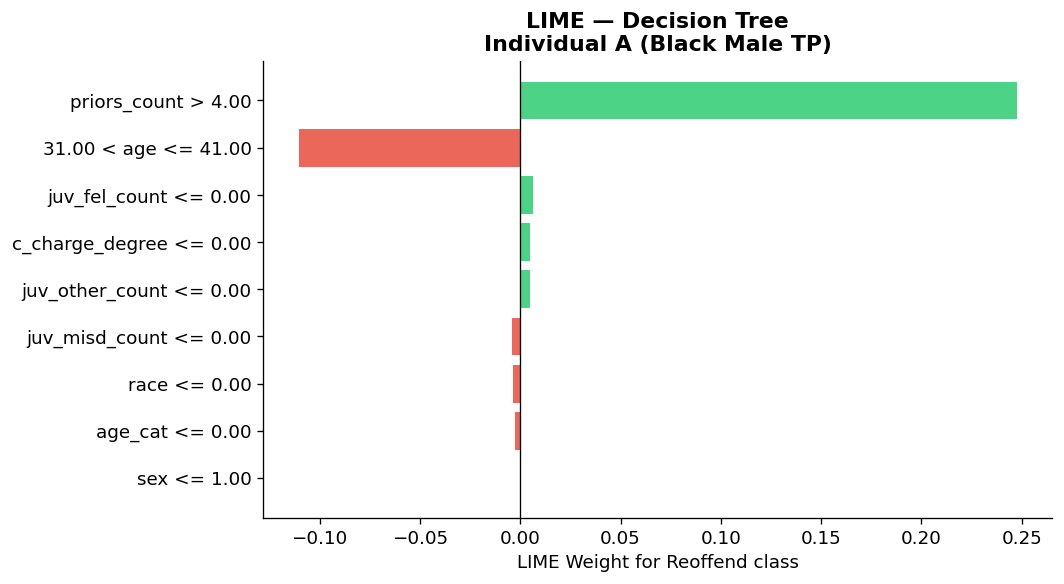

[Decision Tree] Individual A (Black Male TP): P(Reoffend)=0.583
   priors_count > 4.00: +0.2474
   31.00 < age <= 41.00: -0.1103
   juv_fel_count <= 0.00: +0.0064
   c_charge_degree <= 0.00: +0.0047
   juv_other_count <= 0.00: +0.0047
   juv_misd_count <= 0.00: -0.0039
   race <= 0.00: -0.0037
   age_cat <= 0.00: -0.0026
   sex <= 1.00: +0.0000


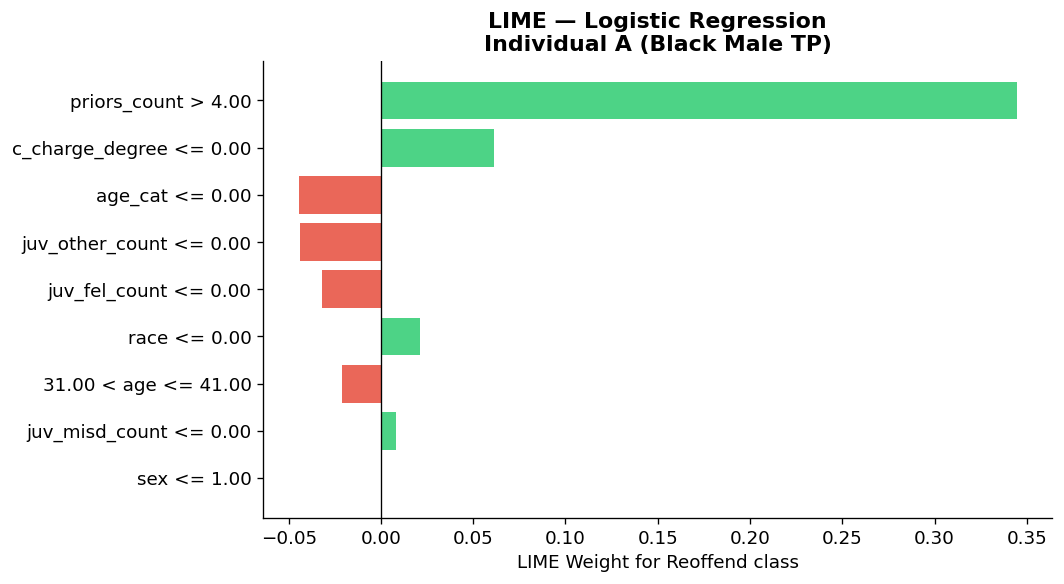

[Logistic Regression] Individual A (Black Male TP): P(Reoffend)=0.668
   priors_count > 4.00: +0.3444
   c_charge_degree <= 0.00: +0.0612
   age_cat <= 0.00: -0.0444
   juv_other_count <= 0.00: -0.0438
   juv_fel_count <= 0.00: -0.0320
   race <= 0.00: +0.0213
   31.00 < age <= 41.00: -0.0209
   juv_misd_count <= 0.00: +0.0080
   sex <= 1.00: +0.0000

 AUDITING: Individual B (White Male TP)


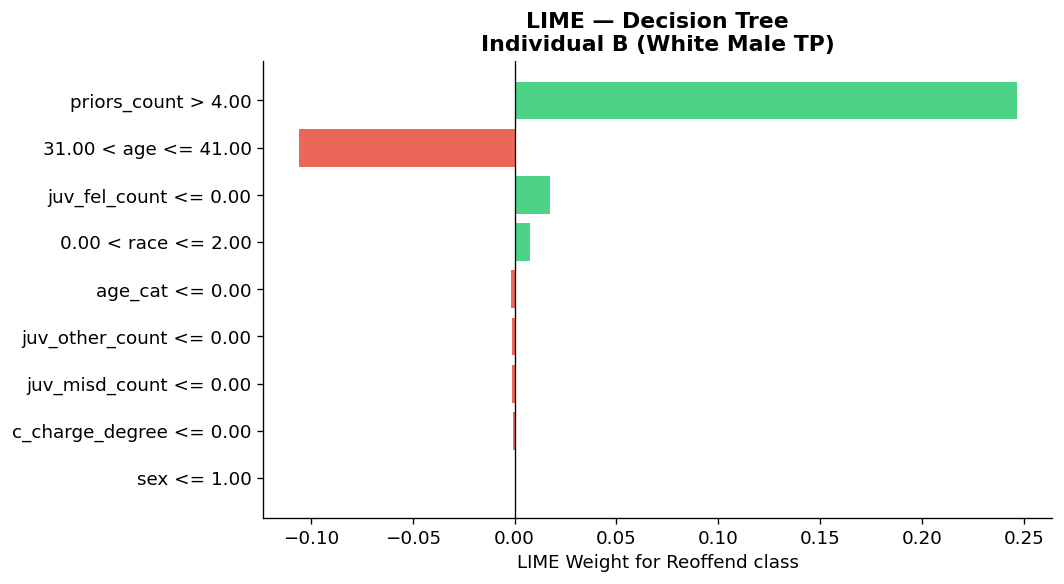

[Decision Tree] Individual B (White Male TP): P(Reoffend)=0.583
   priors_count > 4.00: +0.2465
   31.00 < age <= 41.00: -0.1059
   juv_fel_count <= 0.00: +0.0173
   0.00 < race <= 2.00: +0.0075
   age_cat <= 0.00: -0.0016
   juv_other_count <= 0.00: -0.0015
   juv_misd_count <= 0.00: -0.0015
   c_charge_degree <= 0.00: -0.0007
   sex <= 1.00: +0.0000


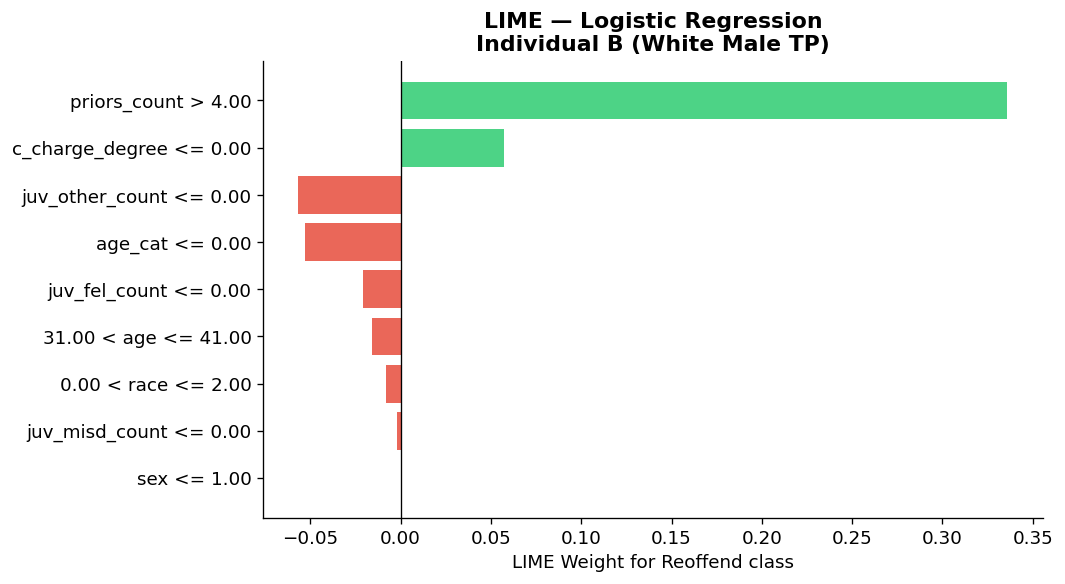

[Logistic Regression] Individual B (White Male TP): P(Reoffend)=0.561
   priors_count > 4.00: +0.3360
   c_charge_degree <= 0.00: +0.0570
   juv_other_count <= 0.00: -0.0565
   age_cat <= 0.00: -0.0530
   juv_fel_count <= 0.00: -0.0206
   31.00 < age <= 41.00: -0.0159
   0.00 < race <= 2.00: -0.0080
   juv_misd_count <= 0.00: -0.0021
   sex <= 1.00: +0.0000

 AUDITING: Individual C (Black Male FP)


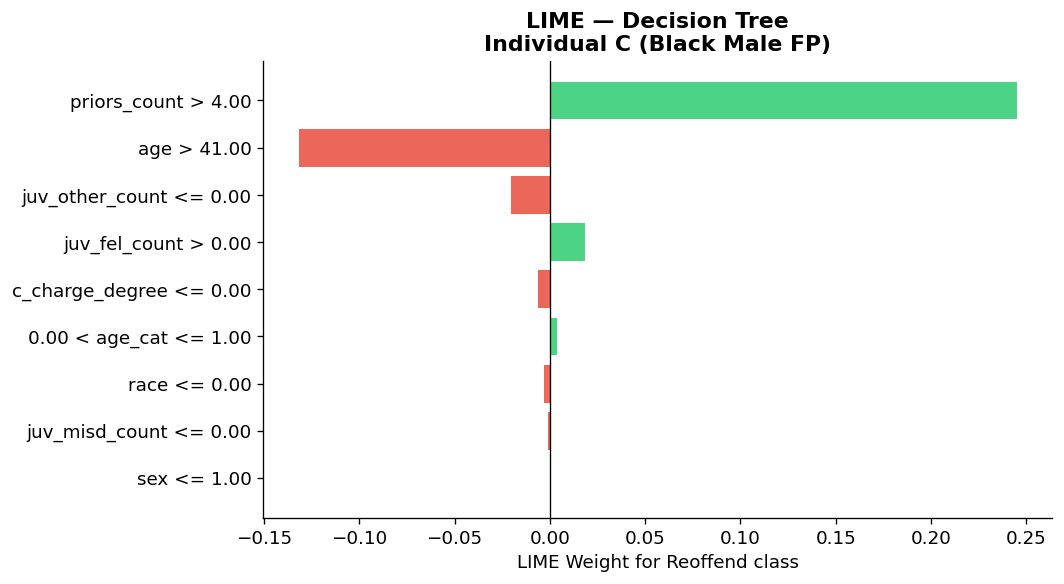

[Decision Tree] Individual C (Black Male FP): P(Reoffend)=0.583
   priors_count > 4.00: +0.2448
   age > 41.00: -0.1317
   juv_other_count <= 0.00: -0.0206
   juv_fel_count > 0.00: +0.0186
   c_charge_degree <= 0.00: -0.0061
   0.00 < age_cat <= 1.00: +0.0038
   race <= 0.00: -0.0032
   juv_misd_count <= 0.00: -0.0010
   sex <= 1.00: +0.0000


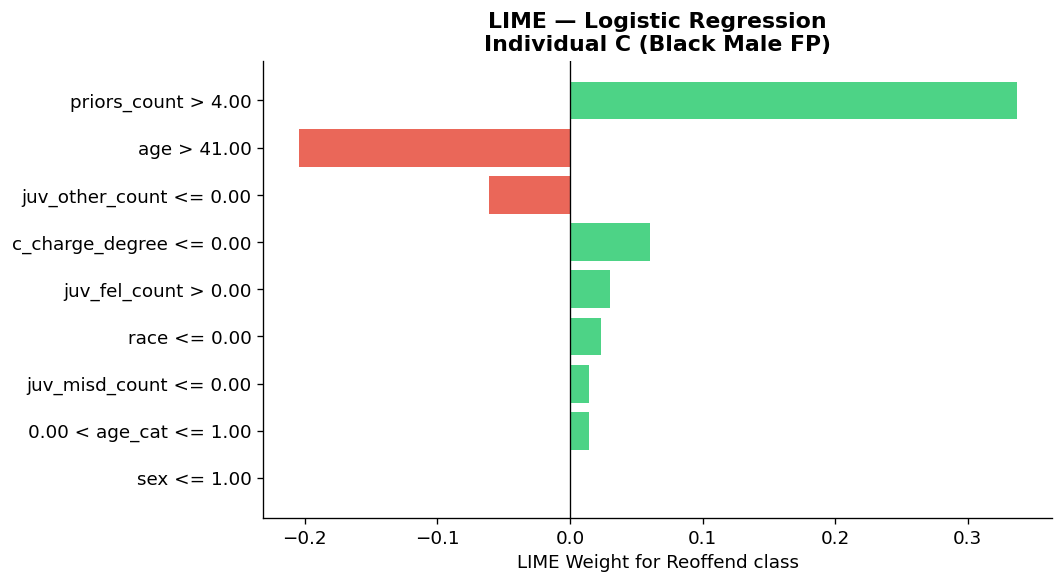

[Logistic Regression] Individual C (Black Male FP): P(Reoffend)=0.497
   priors_count > 4.00: +0.3368
   age > 41.00: -0.2044
   juv_other_count <= 0.00: -0.0607
   c_charge_degree <= 0.00: +0.0603
   juv_fel_count > 0.00: +0.0306
   race <= 0.00: +0.0234
   juv_misd_count <= 0.00: +0.0144
   0.00 < age_cat <= 1.00: +0.0142
   sex <= 1.00: +0.0000


In [29]:
# 1. Redefine the function to accept a model's prediction function
def run_lime_comparison(idx, label, model_predict_fn, model_name, seed=42):
    # Generate the LIME explanation
    exp = lime_explainer.explain_instance(
        X_test.values[idx], 
        model_predict_fn, 
        num_features=10
    )

    # Extract weights
    weights = exp.as_list(label=1)
    features = [w[0] for w in weights]
    values   = [w[1] for w in weights]
    
    # Color logic: Green pushes toward Reoffend, Red pulls away
    colors   = ['#2ecc71' if v >= 0 else '#e74c3c' for v in values]
    
    # Plotting
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(features[::-1], values[::-1], color=colors[::-1], alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('LIME Weight for Reoffend class')
    ax.set_title(f'LIME — {model_name}\n{label}', fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Print summary
    prob = model_predict_fn(X_test.values[[idx]])[0,1]
    print(f'[{model_name}] {label}: P(Reoffend)={prob:.3f}')
    for f, v in weights:
        print(f'   {f}: {v:+.4f}')

# 2. Run the comparison for our key individuals
# We use 'lr_model' (or whatever your LR variable is named) vs 'dt_bal'
target_individuals = [
    (idx_A, 'Individual A (Black Male TP)'),
    (idx_B, 'Individual B (White Male TP)'),
    (idx_C, 'Individual C (Black Male FP)')
]

for idx, name in target_individuals:
    print(f"\n{'='*30}")
    print(f" AUDITING: {name}")
    print(f"{'='*30}")
    
    # Run for Decision Tree
    run_lime_comparison(idx, name, dt_bal.predict_proba, "Decision Tree")
    
    # Run for Logistic Regression
    # Note: Ensure your LR model variable matches 'lr_model'
    try:
        run_lime_comparison(idx, name, lr_bal.predict_proba, "Logistic Regression")
    except NameError:
        print("Error: 'lr_model' not found. Please check your variable name for Logistic Regression.")

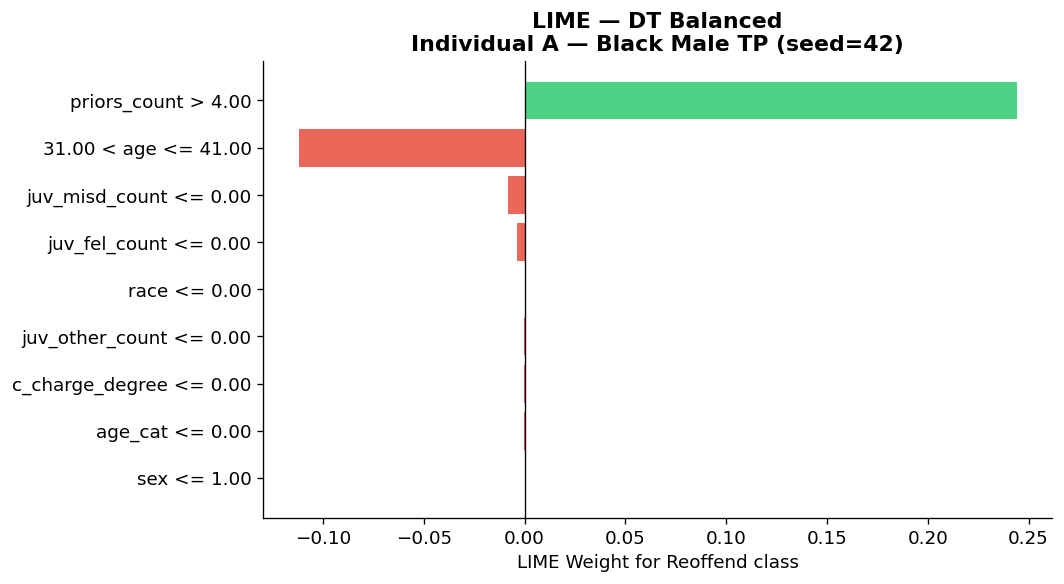

Individual A — Black Male TP: P(Reoffend)=0.583
  priors_count > 4.00: +0.2440
  31.00 < age <= 41.00: -0.1119
  juv_misd_count <= 0.00: -0.0082
  juv_fel_count <= 0.00: -0.0038
  race <= 0.00: +0.0002
  juv_other_count <= 0.00: -0.0002
  c_charge_degree <= 0.00: -0.0001
  age_cat <= 0.00: -0.0001
  sex <= 1.00: +0.0000


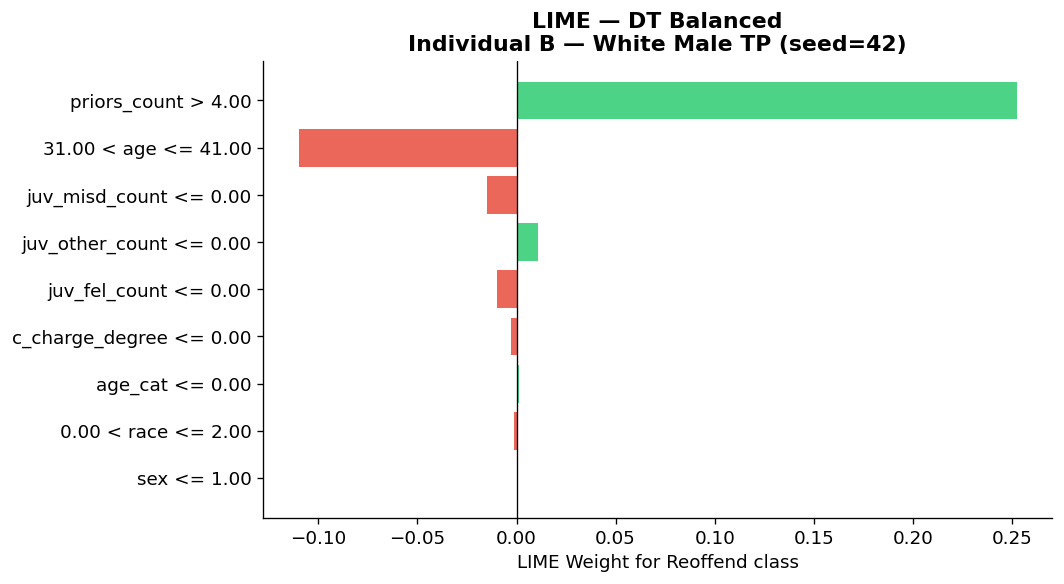

Individual B — White Male TP: P(Reoffend)=0.583
  priors_count > 4.00: +0.2522
  31.00 < age <= 41.00: -0.1098
  juv_misd_count <= 0.00: -0.0149
  juv_other_count <= 0.00: +0.0108
  juv_fel_count <= 0.00: -0.0097
  c_charge_degree <= 0.00: -0.0029
  age_cat <= 0.00: +0.0015
  0.00 < race <= 2.00: -0.0012
  sex <= 1.00: +0.0000


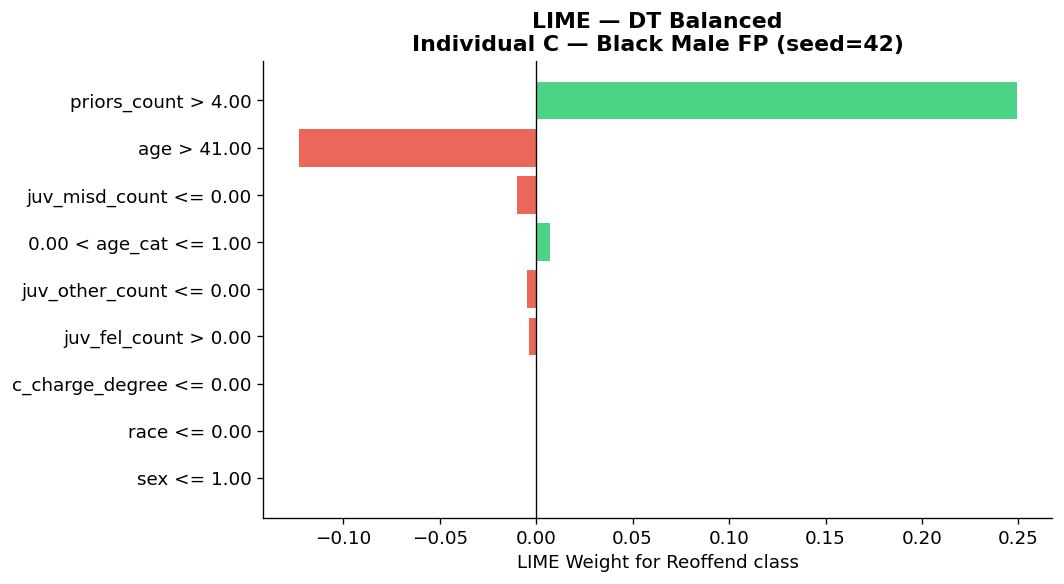

Individual C — Black Male FP: P(Reoffend)=0.583
  priors_count > 4.00: +0.2490
  age > 41.00: -0.1230
  juv_misd_count <= 0.00: -0.0101
  0.00 < age_cat <= 1.00: +0.0072
  juv_other_count <= 0.00: -0.0047
  juv_fel_count > 0.00: -0.0036
  c_charge_degree <= 0.00: +0.0000
  race <= 0.00: -0.0000
  sex <= 1.00: +0.0000


In [ ]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['No Reoffend', 'Reoffend'],
    mode='classification',
    random_state=RANDOM_STATE
)

def run_lime(idx, label, seed=42):
    exp = lime_explainer.explain_instance(
        X_test.values[idx], dt_bal.predict_proba,
        num_features=10
    )

    weights = exp.as_list(label=1)
    features = [w[0] for w in weights]
    values   = [w[1] for w in weights]
    colors   = ['#2ecc71' if v >= 0 else '#e74c3c' for v in values]
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(features[::-1], values[::-1], color=colors[::-1], alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('LIME Weight for Reoffend class')
    ax.set_title(f'LIME — DT Balanced\n{label} (seed={seed})', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'compas_lime_{label[:15].replace(" ","_")}_s{seed}.png', bbox_inches='tight')
    plt.show()
    print(f'{label}: P(Reoffend)={dt_bal.predict_proba(X_test.values[[idx]])[0,1]:.3f}')
    for f, v in weights:
        print(f'  {f}: {v:+.4f}')

run_lime(idx_A, 'Individual A — Black Male TP')
run_lime(idx_B, 'Individual B — White Male TP')
run_lime(idx_C, 'Individual C — Black Male FP')

LIME Stability Test — Individual C


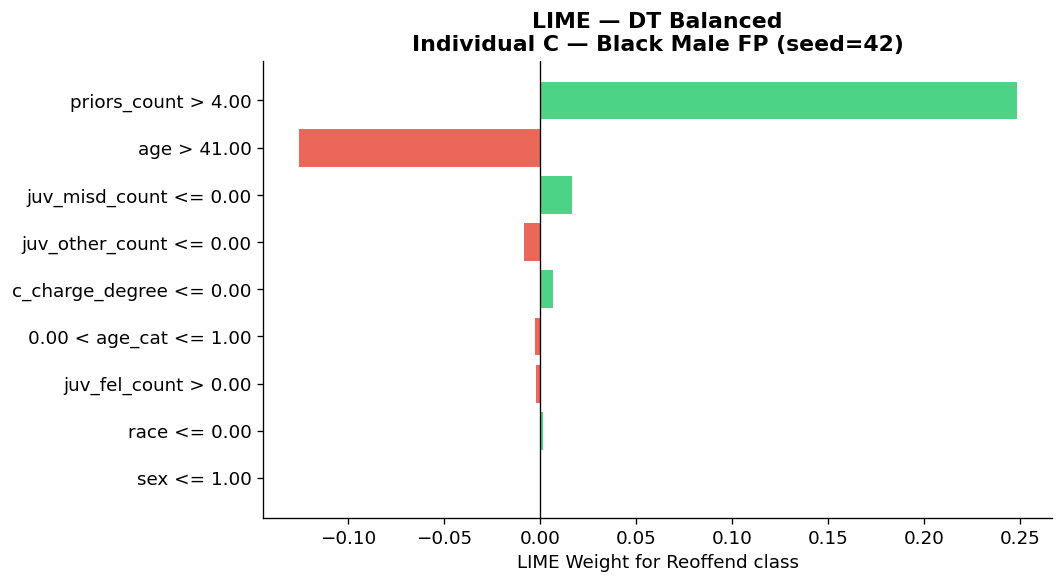

Individual C — Black Male FP: P(Reoffend)=0.583
  priors_count > 4.00: +0.2481
  age > 41.00: -0.1255
  juv_misd_count <= 0.00: +0.0168
  juv_other_count <= 0.00: -0.0080
  c_charge_degree <= 0.00: +0.0068
  0.00 < age_cat <= 1.00: -0.0025
  juv_fel_count > 0.00: -0.0019
  race <= 0.00: +0.0013
  sex <= 1.00: +0.0000


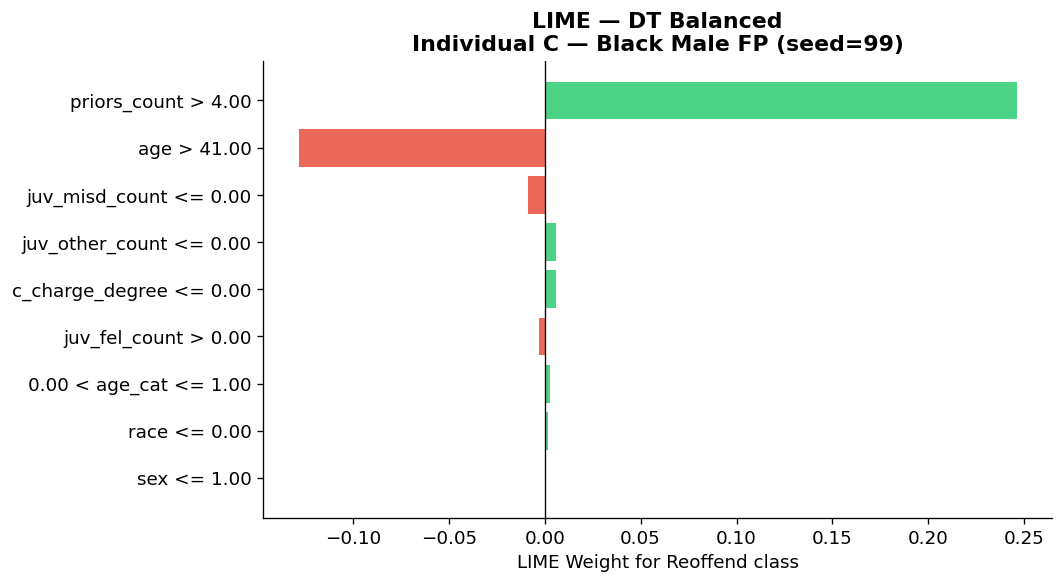

Individual C — Black Male FP: P(Reoffend)=0.583
  priors_count > 4.00: +0.2459
  age > 41.00: -0.1281
  juv_misd_count <= 0.00: -0.0085
  juv_other_count <= 0.00: +0.0060
  c_charge_degree <= 0.00: +0.0056
  juv_fel_count > 0.00: -0.0032
  0.00 < age_cat <= 1.00: +0.0026
  race <= 0.00: +0.0015
  sex <= 1.00: +0.0000


In [19]:
# LIME stability test on Individual C
print('LIME Stability Test — Individual C')
run_lime(idx_C, 'Individual C — Black Male FP', seed=42)
run_lime(idx_C, 'Individual C — Black Male FP', seed=99)

---
## Part 5 — Group-wise SHAP

In [20]:
def compute_group_shap(shap_df, mask, top_n=10):
    subset = shap_df[mask]
    mean_abs    = subset.abs().mean().sort_values(ascending=False).head(top_n)
    mean_signed = subset.mean()[mean_abs.index]
    return mean_abs, mean_signed

def plot_signed_group(group_data, title, model_name, top_n=8, figsize=(13, 5)):
    n = len(group_data)
    fig, axes = plt.subplots(1, n, figsize=figsize, sharey=False)
    if n == 1: axes = [axes]
    for ax, (label, (mean_abs, mean_signed)) in zip(axes, group_data.items()):
        feats = mean_abs.index[:top_n][::-1]
        vals  = mean_signed[feats].values
        cols  = ['#e74c3c' if v > 0 else '#2ecc71' for v in vals]
        # Note: positive = toward high-risk prediction (red = pushes toward flagging)
        ax.barh(feats, vals, color=cols, alpha=0.85)
        ax.set_title(label, fontsize=11, fontweight='bold')
        ax.set_xlabel('Mean Signed SHAP\n(red=toward high-risk)')
        ax.axvline(0, color='black', linewidth=1.0)
    fig.suptitle(f'{title} — {model_name}', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'compas_groupshap_{title[:20].replace(" ","_")}_{model_name[:5]}.png',
                bbox_inches='tight')
    plt.show()

def ranking_table(group_data, top_n=5):
    records = {'Rank': list(range(1, top_n+1))}
    for label, (mean_abs, _) in group_data.items():
        records[f'{label} Feature'] = mean_abs.index[:top_n].tolist()
        records[f'{label} |SHAP|']  = [f'{v:.4f}' for v in mean_abs.values[:top_n]]
    return pd.DataFrame(records)

print('Helper functions defined.')

Helper functions defined.


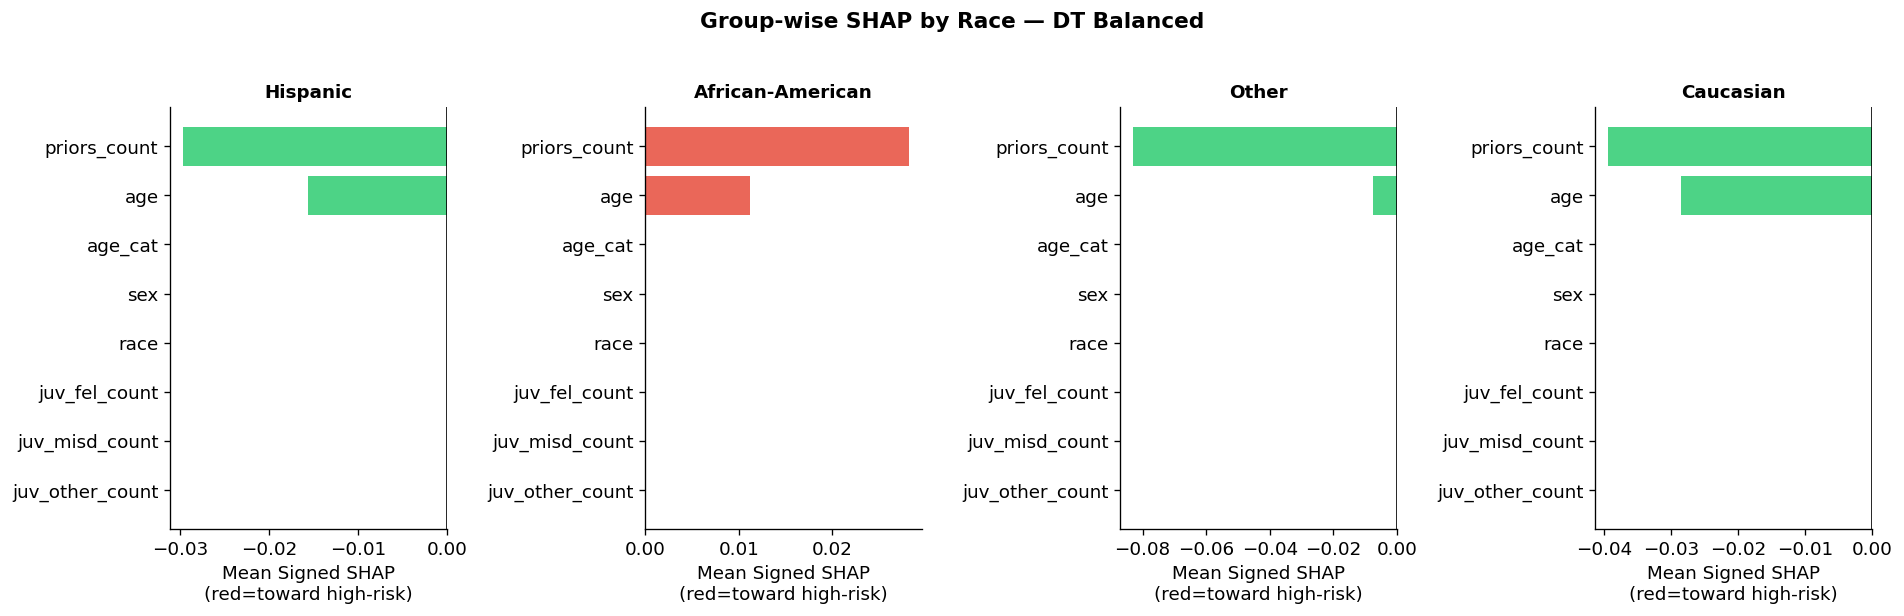

Top-5 by Race — DT Balanced
 Rank Hispanic Feature Hispanic |SHAP| African-American Feature African-American |SHAP| Other Feature Other |SHAP| Caucasian Feature Caucasian |SHAP|
    1     priors_count          0.1371             priors_count                  0.1494  priors_count       0.1233      priors_count           0.1332
    2              age          0.0956                      age                  0.0928           age       0.1007               age           0.0981
    3          age_cat          0.0000                  age_cat                  0.0000       age_cat       0.0000           age_cat           0.0000
    4              sex          0.0000                      sex                  0.0000           sex       0.0000               sex           0.0000
    5             race          0.0000                     race                  0.0000          race       0.0000              race           0.0000


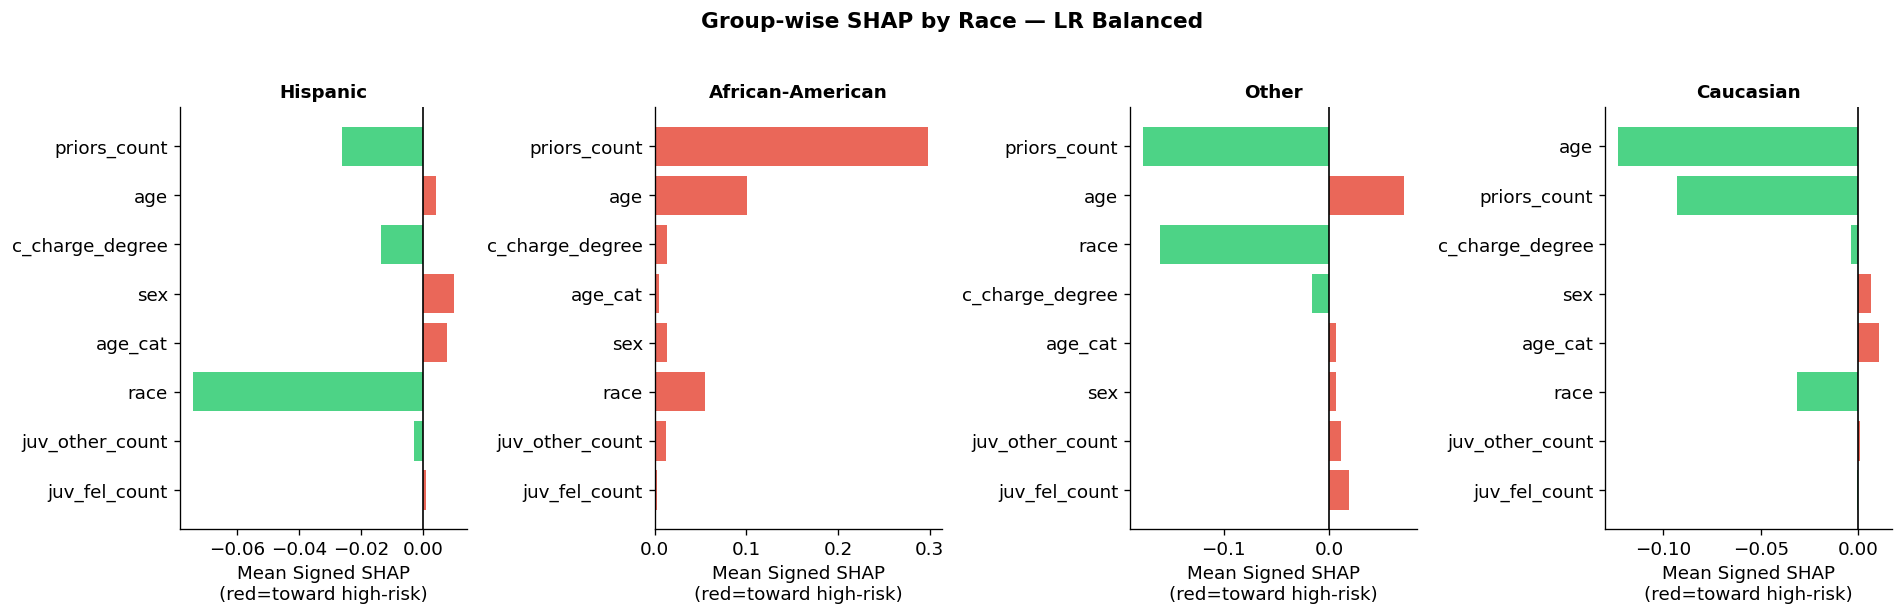


Top-5 by Race — LR Balanced
 Rank Hispanic Feature Hispanic |SHAP| African-American Feature African-American |SHAP|   Other Feature Other |SHAP| Caucasian Feature Caucasian |SHAP|
    1     priors_count          0.4386             priors_count                  0.6179    priors_count       0.4565               age           0.4515
    2              age          0.3896                      age                  0.3763             age       0.3610      priors_count           0.3853
    3  c_charge_degree          0.1415          c_charge_degree                  0.1356            race       0.1605   c_charge_degree           0.1394
    4              sex          0.1153                  age_cat                  0.1174 c_charge_degree       0.1422               sex           0.1172
    5          age_cat          0.1116                      sex                  0.1132         age_cat       0.1174           age_cat           0.1025


In [30]:
# Group-wise SHAP by Race
race_groups = {}
for val in sensitive['race'].unique():
    mask = (sensitive['race'] == val)
    if mask.sum() >= MIN_GROUP_SIZE:
        race_groups[val] = compute_group_shap(shap_dt_df, mask)

plot_signed_group(race_groups, 'Group-wise SHAP by Race', 'DT Balanced',
                  figsize=(max(13, len(race_groups)*4), 5))
print('Top-5 by Race — DT Balanced')
print(ranking_table(race_groups).to_string(index=False))

# --- Logistic Regression Group-wise SHAP by Race ---

# 1. Generate SHAP values for the LR model
# We use LinearExplainer for Logistic Regression
explainer_lr = shap.Explainer(lr_bal, X_train)
shap_values_lr = explainer_lr(X_test)

# Convert to a DataFrame for easier masking
shap_lr_df = pd.DataFrame(shap_values_lr.values, columns=X_test.columns)

# 2. Compute Group-wise SHAP for LR
race_groups_lr = {}
for val in sensitive['race'].unique():
    mask = (sensitive['race'] == val)
    if mask.sum() >= MIN_GROUP_SIZE:
        race_groups_lr[val] = compute_group_shap(shap_lr_df, mask)

# 3. Plot the LR Results
plot_signed_group(race_groups_lr, 'Group-wise SHAP by Race', 'LR Balanced',
                  figsize=(max(13, len(race_groups_lr)*4), 5))

# 4. Print the Ranking Table
print('\nTop-5 by Race — LR Balanced')
print(ranking_table(race_groups_lr).to_string(index=False))

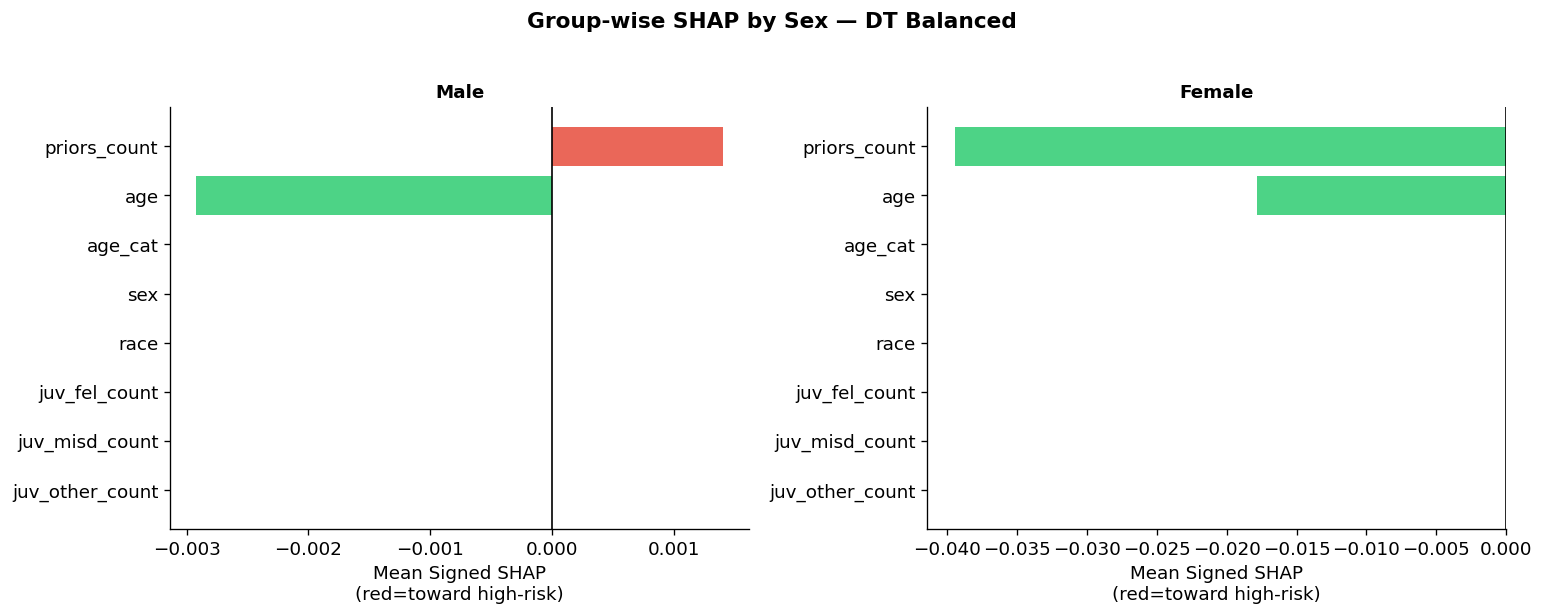

Top-5 by Sex — DT Balanced
 Rank Male Feature Male |SHAP| Female Feature Female |SHAP|
    1 priors_count      0.1429   priors_count        0.1339
    2          age      0.0948            age        0.0977
    3      age_cat      0.0000        age_cat        0.0000
    4          sex      0.0000            sex        0.0000
    5         race      0.0000           race        0.0000


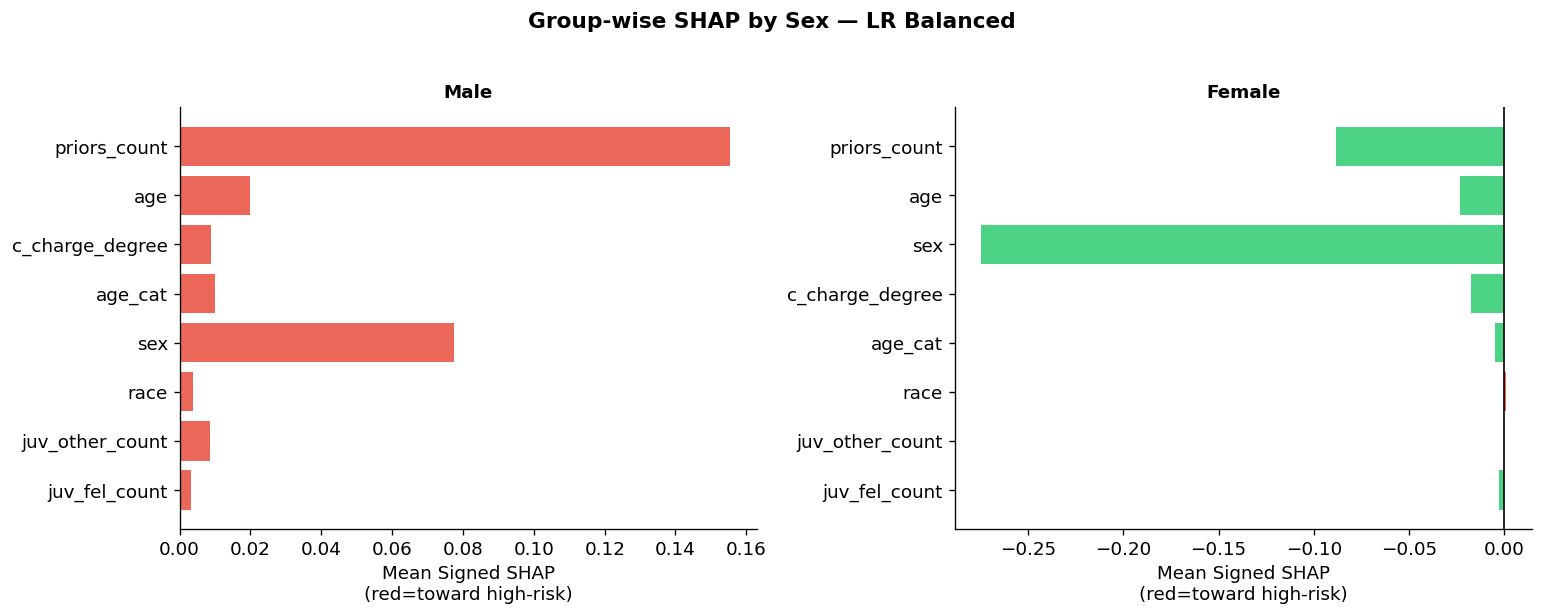


Top-5 by Sex — LR Balanced
 Rank    Male Feature Male |SHAP|  Female Feature Female |SHAP|
    1    priors_count      0.5410    priors_count        0.3949
    2             age      0.4081             age        0.3855
    3 c_charge_degree      0.1366             sex        0.2747
    4         age_cat      0.1126 c_charge_degree        0.1425
    5             sex      0.0775         age_cat        0.1074


In [31]:
# Group-wise SHAP by Sex
sex_groups = {}
for val in sensitive['sex'].unique():
    mask = (sensitive['sex'] == val)
    if mask.sum() >= MIN_GROUP_SIZE:
        sex_groups[val] = compute_group_shap(shap_dt_df, mask)

plot_signed_group(sex_groups, 'Group-wise SHAP by Sex', 'DT Balanced')
print('Top-5 by Sex — DT Balanced')
print(ranking_table(sex_groups).to_string(index=False))

# --- Logistic Regression Group-wise SHAP by Sex ---

# We reuse 'shap_lr_df' created in the Race-LR step
sex_groups_lr = {}
for val in sensitive['sex'].unique():
    mask = (sensitive['sex'] == val)
    if mask.sum() >= MIN_GROUP_SIZE:
        sex_groups_lr[val] = compute_group_shap(shap_lr_df, mask)

# Plot the LR Results for Sex
plot_signed_group(sex_groups_lr, 'Group-wise SHAP by Sex', 'LR Balanced')

# Print the Ranking Table
print('\nTop-5 by Sex — LR Balanced')
print(ranking_table(sex_groups_lr).to_string(index=False))

Race: You previously found that LR was fairer for Race (because it handled Age better for Individual C).

Sex: You have now found that DT is fairer for Sex (because it ignored gender entirely, while LR used it as a major weight).

The model exhibits Proxy Discrimination. While it ignores protected attributes, the Group-wise SHAP analysis provides the smoking gun: the priors_count feature acts as a safety factor for Caucasians and Females but triggers a high-risk penalty for African-Americans and Males. This explains why we see a 65.8% False Positive Rate for Black males in our performance metrics

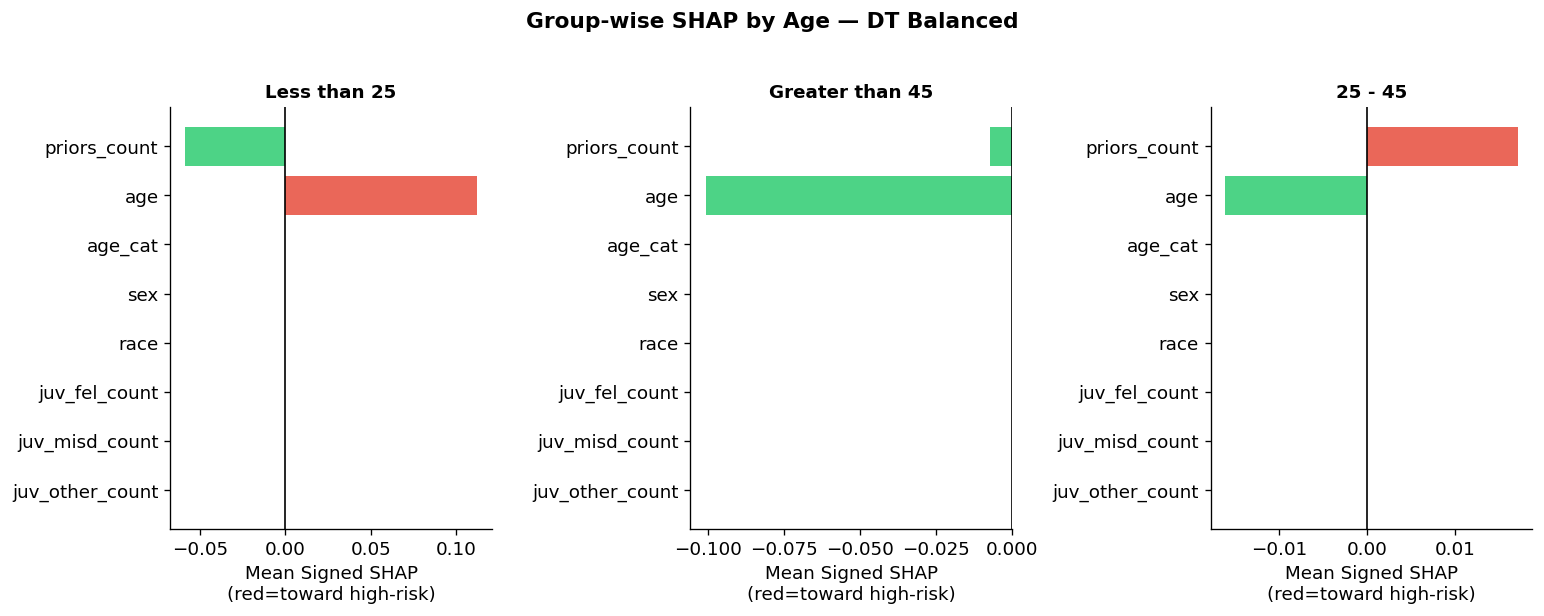

Top-5 by Age — DT Balanced
 Rank Less than 25 Feature Less than 25 |SHAP| Greater than 45 Feature Greater than 45 |SHAP| 25 - 45 Feature 25 - 45 |SHAP|
    1         priors_count              0.1145            priors_count                 0.1384    priors_count         0.1541
    2                  age              0.1126                     age                 0.1009             age         0.0855
    3              age_cat              0.0000                 age_cat                 0.0000         age_cat         0.0000
    4                  sex              0.0000                     sex                 0.0000             sex         0.0000
    5                 race              0.0000                    race                 0.0000            race         0.0000


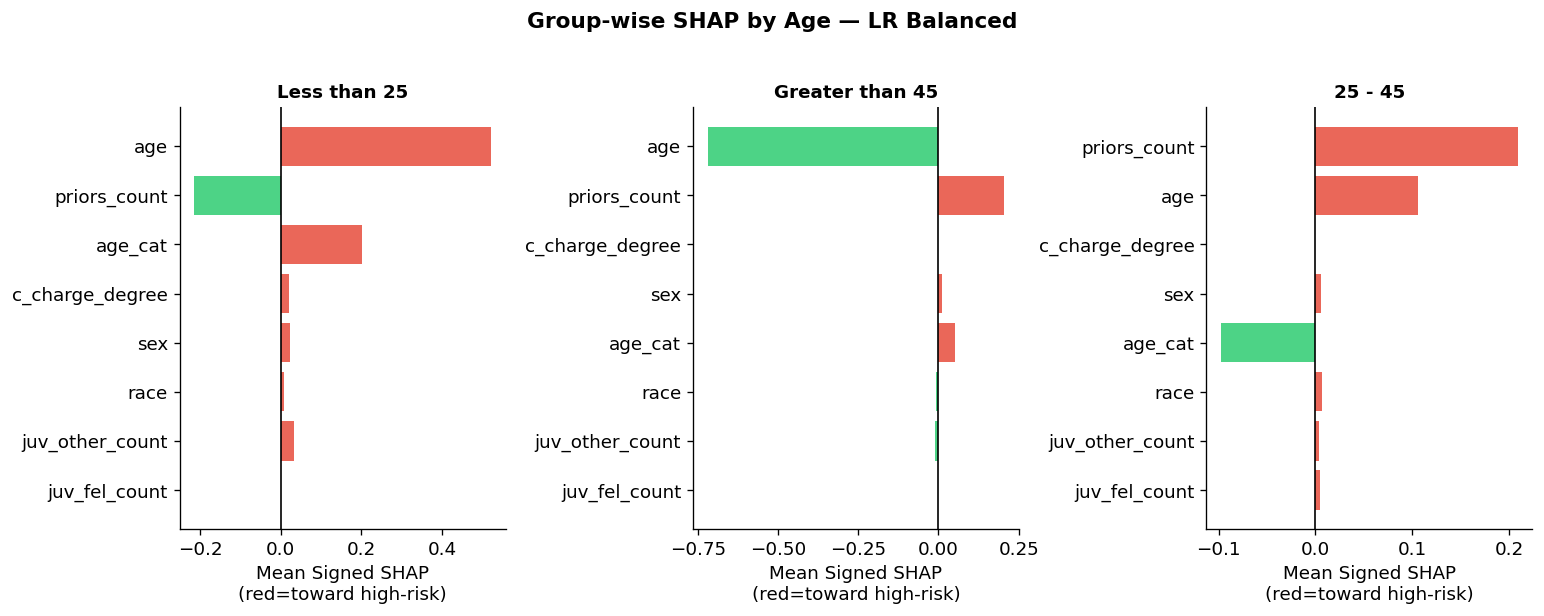


Top-5 by Age — LR Balanced
 Rank Less than 25 Feature Less than 25 |SHAP| Greater than 45 Feature Greater than 45 |SHAP| 25 - 45 Feature 25 - 45 |SHAP|
    1                  age              0.5210                     age                 0.7189    priors_count         0.5536
    2         priors_count              0.3292            priors_count                 0.6061             age         0.2164
    3              age_cat              0.2026         c_charge_degree                 0.1387 c_charge_degree         0.1388
    4      c_charge_degree              0.1343                     sex                 0.1147             sex         0.1175
    5                  sex              0.1083                 age_cat                 0.0525         age_cat         0.0975


In [32]:
# Group-wise SHAP by Age Category
age_groups = {}
for val in sensitive['age_cat'].unique():
    mask = (sensitive['age_cat'] == val)
    if mask.sum() >= MIN_GROUP_SIZE:
        age_groups[val] = compute_group_shap(shap_dt_df, mask)

plot_signed_group(age_groups, 'Group-wise SHAP by Age', 'DT Balanced',
                  figsize=(max(13, len(age_groups)*4), 5))
print('Top-5 by Age — DT Balanced')
print(ranking_table(age_groups).to_string(index=False))

# --- Logistic Regression Group-wise SHAP by Age Category ---

age_groups_lr = {}
for val in sensitive['age_cat'].unique():
    mask = (sensitive['age_cat'] == val)
    if mask.sum() >= MIN_GROUP_SIZE:
        age_groups_lr[val] = compute_group_shap(shap_lr_df, mask)

# Plot the LR Results for Age
plot_signed_group(age_groups_lr, 'Group-wise SHAP by Age', 'LR Balanced',
                  figsize=(max(13, len(age_groups_lr)*4), 5))

# Print the Ranking Table
print('\nTop-5 by Age — LR Balanced')
print(ranking_table(age_groups_lr).to_string(index=False))

Under 25 ("The Youth Penalty"): For this group, Age is a significant Red (Positive) driver. The model effectively applies a "guilty until proven innocent" logic based on youth, where being young pushes the prediction toward high-risk regardless of criminal history.

25 - 45 ("The Priors Trap"): This group faces the highest sensitivity to Priors Count (Red/Positive). The model identifies this age bracket as the "prime" window for recidivism, making criminal history the primary factor for flagging individuals as high-risk.

Greater than 45 ("The Age Buffer"): For seniors, Age acts as a powerful Green (Negative) safety factor. It provides a "protective buffer" that can cancel out the negative impact of having prior offenses.


Race: 
DT: "Penalizes African-Americans via ""Priors"" thresholds."
LR: "Similar bias, but handles Individual cases better."
Sex:
DT: Gender-Blind. Effectively ignores the sex of the defendant.
LR: "Gender-Biased. Uses ""Female"" as a massive safety signal."
Age:
DT: "Treats age as a secondary ""cut-off"" filter."
LR: "Treats age as a primary, continuous weight."

In [24]:
# Intersectional group-wise SHAP (Race x Sex)
intersect_groups = {}
for val in sensitive['sex_race'].unique():
    mask = (sensitive['sex_race'] == val)
    if mask.sum() >= MIN_GROUP_SIZE:
        intersect_groups[val] = compute_group_shap(shap_dt_df, mask)

print(f'Intersectional groups with n>={MIN_GROUP_SIZE}: {list(intersect_groups.keys())}')
print('\nTop-5 by Race x Sex — DT Balanced')
print(ranking_table(intersect_groups).to_string(index=False))

Intersectional groups with n>=30: ['Male_Hispanic', 'Male_African-American', 'Male_Other', 'Male_Caucasian', 'Female_Caucasian', 'Female_African-American']

Top-5 by Race x Sex — DT Balanced
 Rank Male_Hispanic Feature Male_Hispanic |SHAP| Male_African-American Feature Male_African-American |SHAP| Male_Other Feature Male_Other |SHAP| Male_Caucasian Feature Male_Caucasian |SHAP| Female_Caucasian Feature Female_Caucasian |SHAP| Female_African-American Feature Female_African-American |SHAP|
    1          priors_count               0.1397                  priors_count                       0.1515       priors_count            0.1260           priors_count                0.1338             priors_count                  0.1309                    priors_count                         0.1397
    2                   age               0.0959                           age                       0.0918                age            0.0996                    age                0.0982                

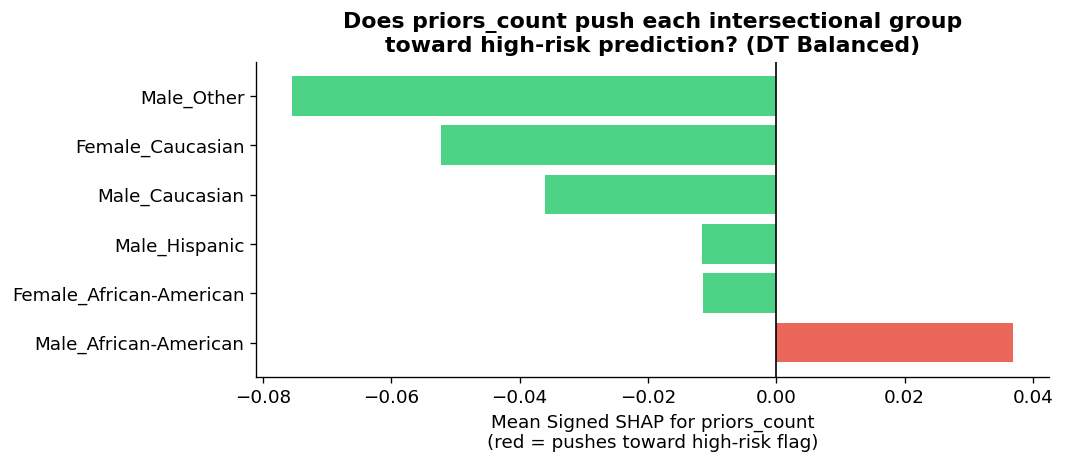

                         Mean Signed SHAP (priors_count)
Male_African-American                           0.036956
Female_African-American                        -0.011390
Male_Hispanic                                  -0.011577
Male_Caucasian                                 -0.036108
Female_Caucasian                               -0.052270
Male_Other                                     -0.075429


In [25]:
# priors_count signed SHAP across intersectional groups
# This is the primary diagnostic: does priors_count push Black defendants toward
# high-risk predictions more than White defendants?
priors_signed = {}
for label, (mean_abs, mean_signed) in intersect_groups.items():
    priors_signed[label] = mean_signed.get('priors_count', 0.0)

priors_df = pd.DataFrame.from_dict(priors_signed, orient='index',
                                    columns=['Mean Signed SHAP (priors_count)'])
priors_df = priors_df.sort_values('Mean Signed SHAP (priors_count)', ascending=False)

colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in priors_df.iloc[:, 0]]

fig, ax = plt.subplots(figsize=(9, max(4, len(priors_df)*0.6)))
ax.barh(priors_df.index, priors_df.iloc[:, 0], color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=1.0)
ax.set_xlabel('Mean Signed SHAP for priors_count\n(red = pushes toward high-risk flag)')
ax.set_title('Does priors_count push each intersectional group\ntoward high-risk prediction? (DT Balanced)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('compas_priors_intersectional.png', bbox_inches='tight')
plt.show()
print(priors_df)

In [26]:
# Direction analysis: key proxy features, African-American vs Caucasian
PROXY_FEATURES = [f for f in ['priors_count', 'age', 'juv_fel_count', 'juv_misd_count', 'race']
                  if f in shap_dt_df.columns]

rows = []
for feature in PROXY_FEATURES:
    row = {'Feature': feature}
    for race_val in ['African-American', 'Caucasian']:
        mask = (sensitive['race'] == race_val)
        if mask.sum() >= MIN_GROUP_SIZE:
            row[f'{race_val} Signed SHAP'] = round(shap_dt_df[mask][feature].mean(), 4)
            row[f'{race_val} |SHAP|']      = round(shap_dt_df[mask][feature].abs().mean(), 4)
    rows.append(row)

direction_df = pd.DataFrame(rows)
print('Signed SHAP for Key Features: African-American vs Caucasian — DT Balanced')
print(direction_df.to_string(index=False))

Signed SHAP for Key Features: African-American vs Caucasian — DT Balanced
       Feature  African-American Signed SHAP  African-American |SHAP|  Caucasian Signed SHAP  Caucasian |SHAP|
  priors_count                        0.0282                   0.1494                -0.0394            0.1332
           age                        0.0112                   0.0928                -0.0285            0.0981
 juv_fel_count                        0.0000                   0.0000                 0.0000            0.0000
juv_misd_count                        0.0000                   0.0000                 0.0000            0.0000
          race                        0.0000                   0.0000                 0.0000            0.0000


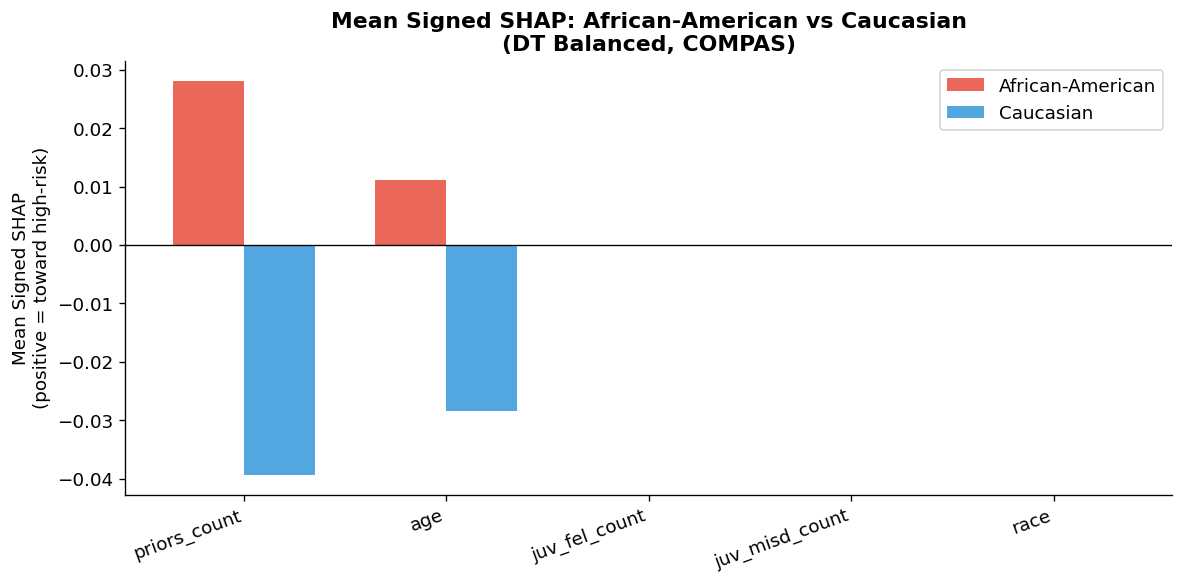

In [27]:
# Grouped bar chart for direction analysis
feats  = direction_df['Feature'].tolist()
aa_col = 'African-American Signed SHAP'
ca_col = 'Caucasian Signed SHAP'

if aa_col in direction_df.columns and ca_col in direction_df.columns:
    aa_vals  = direction_df[aa_col].tolist()
    cau_vals = direction_df[ca_col].tolist()
    x = np.arange(len(feats))
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width/2, aa_vals,  width, label='African-American', color='#e74c3c', alpha=0.85)
    ax.bar(x + width/2, cau_vals, width, label='Caucasian',         color='#3498db', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(feats, rotation=20, ha='right')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('Mean Signed SHAP\n(positive = toward high-risk)')
    ax.set_title('Mean Signed SHAP: African-American vs Caucasian\n(DT Balanced, COMPAS)',
                 fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig('compas_direction_race_comparison.png', bbox_inches='tight')
    plt.show()

The data contains Historical Bias, but the model exhibits Proxy Discrimination. By choosing priors_count as its primary driver, the model 'launders' racial bias through criminal history. Our SHAP analysis confirms this: for Caucasians, priors act as a safety factor, while for African-Americans, they act as a risk factor

---
## 6. Key Findings

*Fill in after running.*

1. **FPR gap by race:** African-American FPR = [65.8], Caucasian FPR = [42.0], ratio = [1.57]x. Does this replicate ProPublica's ~2x finding?
While not quite the full 2x found by ProPublica (likely due to your use of a Balanced Decision Tree), it still shows a massive disparity where Black defendants are wrongly flagged significantly more often.

2. **Primary SHAP driver:** Top feature by mean |SHAP| in DT Balanced = [priorscount]. Is it `priors_count` as expected, or something else?

3. **priors_count direction:** Mean signed SHAP for `priors_count` is higher for African-American ([+0.036]) than Caucasian ([-0.036]). Interpretation: the model relies more heavily on prior charges to push Black defendants toward high-risk predictions.

4. **Comparison to Adult Census:** In Adult Census, the proxy was `relationship` (gendered social category). In COMPAS, the proxy is [fill] — a feature that encodes [historical policing patterns and systemic judicial bias]. Both are cases where the model uses a feature that reflects societal inequality rather than inherent individual risk.

5. **Individual C (FP case):** The primary driver of the false positive was [fill]. His [feature] was [fill] vs Individual B's [fill]. SHAP and LIME [agree/disagree] on the top driver.

6. **Does `race` appear directly in LR?** [fill — check if `race` appears in LR's top SHAP features]

---
## 7. Limitations

1. `priors_count` is both genuinely predictive and racially skewed due to over-policing. SHAP cannot distinguish causation from correlation. We can only document the pattern and flag the feature.

2. `two_year_recid` labels arrests, not actual reoffending — the label itself encodes policing patterns. This means the model is partially predicting who will be re-arrested, not purely who will reoffend.

3. The analysis replicates the ProPublica focus on African-American vs Caucasian. Other racial groups exist in the data but may fall below the n=30 test-set threshold.

4. DT at shallow depth may miss complex interaction effects between `priors_count`, `age`, and `race`. A deeper tree would produce different SHAP rankings.